# Credit Risk Prediction

**Author: Aseem Deshpande**

In this project, we shall try to determine whether or not an individual should be approved to borrow on the basis of their credit behaviour. Using the data at hand, we shall calculate probabilities of an account committing a serious delinquency in the next 2 years using a Logistic Regression model; then we shall compute an expected cost function that accounts for the loss on approving a customer with a high probability of default, and the opportunity cost of denying a customer with a moderate probability of default; hence our objective becomes to minimize this expected cost function, allowing us to make better lending decisions. We shall conduct a series of statistical tests at decision points to make sure that as far as possible, no decision is being made subjectively. We shall also compare our model with a benchmark xgBoost model and decide whether an improvement in performance, if any, is significant enought to choose a model with lower interpretability.

## 1. Project Objective

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## 2. Dataset and Target

### Dataset
In this project, we will be using the 'Give Me Some Credit' dataset from Kaggle. This dataset was made available for a competition, with the objective being to use Machine Learning techniques to determine whether a customer will default in the next two years.

We shall now explore the dataset for missing values, outliers, invalid entries, inconsistencies, etc.

In [2]:
df = pd.read_csv('cs-training.csv')

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Let us understand all of our variables first-

1. 'SeriousDLqin2yrs': This is our target variable. A serious delinquency is an account which is 90 days or more past due. It is a binary variable, and classifies whether the individual has faced financial distress over the last two years
2. 'RevolvingUtilizationOfUnsecuredLines': Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits. Should be noted that this variable does not say anything about the time at which it was measured or if it was measured/averaged over an interval; could be a potential data limitation
3. 'age'
4. 'NumberOfTimes30-59DaysPastDueNotWorse'
5. 'DebtRatio': Ratio of the total monthly debt payments to the gross monthly income
6. 'MonthlyIncome'
7. 'NumberOfOpenCreditLinesAndLoans'
8. 'NumberOfTimes90DaysLate'
9. 'NumberRealEstateLoansorLines'
10. 'NumberOfTimes60-89DaysPastDueNotWorse'
11. 'NumberOfDependents'f


## Initial Hypotheses

| Variable | Expected relationship with financial distress | Reasoning |
|---|---|---|
| `RevolvingUtilizationOfUnsecuredLines` | Strong | Higher revolving utilization ratios can indicate reduced cash flow or risky expenditure |
| `age` | Moderate, Non-linear | Younger people might not have stable jobs yet while older people might be retired, meaning their fixed income has a lower threshold; middle aged people will probably be conscious of their spending habits |
| `NumberOfTime30-59DaysPastDueNotWorse` | Strong | Categorized as a delinquency, indicates bad repayment habits |
| `DebtRatio` | Strong | Debt obligations relative to income |
| `MonthlyIncome` | Moderate | Income is not necessarily an indicator of whether the individual is good at limiting their credit utilization |
| `NumberOfOpenCreditLinesAndLoans` | Moderate | It is just an indicator of number of open accounts, may increase credit risk associated with that individual |
| `NumberOfTimes90DaysLate` | Strong | Serious delinquency |
| `NumberRealEstateLoansOrLines` | Moderate | This type of debt is secured by an asset, might still have a strfong relationship with the target, is a subset of one of the previous variables |
| `NumberOfTime60-89DaysPastDueNotWorse` | Strong | Moderate to severe delinquency |
| `NumberOfDependents` | Strong | More the number of dependents, more the expenditure |

In [4]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

In [6]:
df.isnull().sum()

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [7]:
df.shape

(150000, 12)

In [8]:
df['MonthlyIncome'].agg(['mean', 'median', 'min', 'max', 'std'])

mean      6.670221e+03
median    5.400000e+03
min       0.000000e+00
max       3.008750e+06
std       1.438467e+04
Name: MonthlyIncome, dtype: float64

In [9]:
df['MonthlyIncome'].value_counts()

MonthlyIncome
5000.0     2757
4000.0     2106
6000.0     1934
3000.0     1758
0.0        1634
           ... 
16084.0       1
10523.0       1
55250.0       1
9242.0        1
7647.0        1
Name: count, Length: 13594, dtype: int64

In [10]:
df['NumberOfDependents'].value_counts()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

In [11]:
df['NumberOfDependents'].isna().sum()

np.int64(3924)

<Axes: >

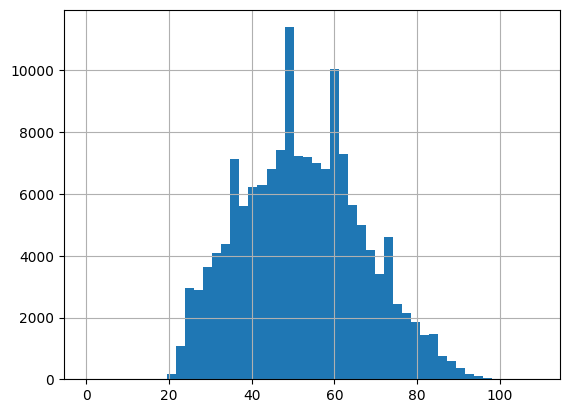

In [12]:
df['age'].hist(bins=50)

In [13]:
df['age'].agg(['mean', 'median', 'min', 'max', 'std'])

mean       52.295207
median     52.000000
min         0.000000
max       109.000000
std        14.771866
Name: age, dtype: float64

In [14]:
df[df['age']== 0]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [15]:
df['age'].value_counts()

age
49     3837
48     3806
50     3753
47     3719
63     3719
       ... 
102       3
109       2
107       1
105       1
0         1
Name: count, Length: 86, dtype: int64

In [16]:
df[df['age'] <= 18]

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,65696,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


From the initial exploration, we can see the following:
- The variable 'MonthlyIncome' has a large number of missing entries(~20%); since there are entries indicating zero monthly income, these might be genuine missing entries, and the number is too large to just drop the missing entries. We will have to determine whether to use imputation, and if yes, what statistic to impute it with.
- The variable 'NumberOfDependents' has a small number of missing entries(~2%). We may simply drop the entries or choose to impute with the appropriate statistic, but before making a decision, we must first deal with the missing entries in the monthly income column.
- The variable 'age' has one invalid entry; there is one entry with age 0, and no other entry with age <= 18. Since this is an obvious data entry, we can choose to ignore this entry.

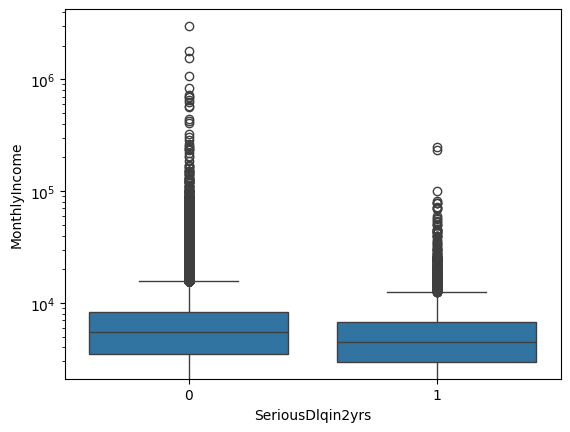

In [17]:
sns.boxplot(x='SeriousDlqin2yrs', y='MonthlyIncome', data=df)
plt.yscale('log')
plt.show()

Consider the boxplot to understand the distribution of the monthly income with respect to the target variable; the outliers most probably do not indicate any error in recording the data, income is just a variable with high variance. (We have used a logarithmic scale to make the boxplot more visually interpretable.)

<Axes: >

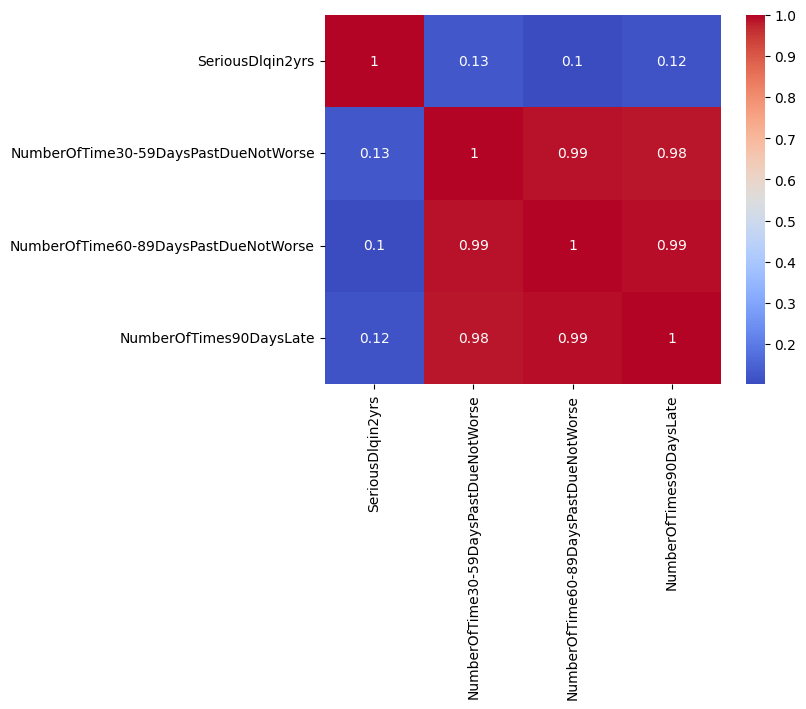

In [18]:
sns.heatmap(df[['SeriousDlqin2yrs', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']].corr(), annot=True, cmap='coolwarm')

In [19]:
df['RevolvingUtilizationOfUnsecuredLines'].agg(['mean', 'median', 'min', 'max', 'std'])

mean          6.048438
median        0.154181
min           0.000000
max       50708.000000
std         249.755371
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

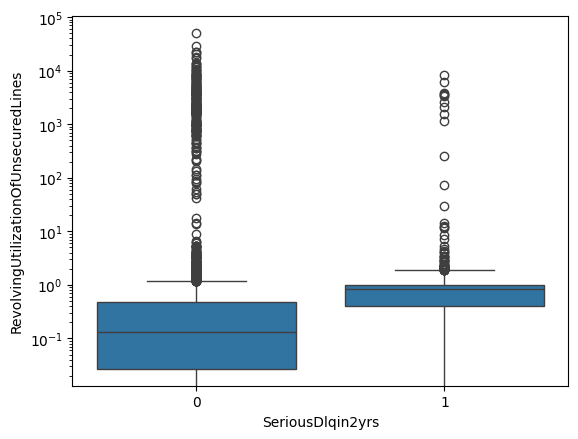

In [20]:
sns.boxplot(x='SeriousDlqin2yrs', y='RevolvingUtilizationOfUnsecuredLines', data=df)   
plt.yscale('log')
plt.show()

In [21]:
df['RevolvingUtilizationOfUnsecuredLines'].nlargest(20)

85489     50708.0
31414     29110.0
16956     22198.0
149160    22000.0
149279    20514.0
117315    18300.0
21978     17441.0
124533    13930.0
72592     13498.0
71705     13400.0
125718    12369.0
58852     11843.0
83052     11553.0
76726     10821.0
13669     10209.0
123071    10151.0
50695      9684.0
8199       9340.0
60021      9193.0
99651      8831.0
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [22]:
df[df['RevolvingUtilizationOfUnsecuredLines'] <=5].shape

(149746, 12)

In [23]:
df['RevolvingUtilizationOfUnsecuredLines'].quantile(0.99)

np.float64(1.0929557681400022)

The variable 'RevolvingUtilizationOfUnsecuredLines' represents the ratio of outstanding debt on unsecured credit lines to the credit limit on that line. It can potentially exceed 1, in cases where interest is levied upon late payments, or credit limit is reduced by the lender. 

Even then, it is extremely rare for this ratio to exceed 5. Since our data has only about 250 observations exceeding 5, and the 99th percentile is 1.09, we can take a decision to disregard the outliers.

## 3. Data Quality and Preprocessing

We shall continue exploring our data, more specifically, try to see whether missingness in variables such as monthly income represents anything.

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
nan_inc = df[df['MonthlyIncome'].isna()]
nan_inc.head(10)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
6,7,0,0.305682,57,0,5710.0,NaN,8,0,3,0,0.0
8,9,0,0.116951,27,0,46.0,NaN,2,0,0,0,NaN
16,17,0,0.061086,78,0,2058.0,NaN,10,0,2,0,0.0
32,33,0,0.083418,62,0,977.0,NaN,6,0,1,0,0.0
41,42,0,0.072898,81,0,75.0,NaN,7,0,0,0,0.0
52,53,0,1.000000,62,0,0.0,NaN,1,0,0,0,0.0
58,59,0,0.541109,43,0,2477.0,NaN,3,0,1,0,2.0
62,63,0,0.101156,72,0,1720.0,NaN,12,0,2,0,0.0
71,72,0,0.142013,67,0,1824.0,NaN,7,0,2,0,0.0
86,87,0,0.360510,58,1,3282.0,NaN,8,0,2,0,0.0


In [26]:
nan_inc['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    28062
1     1669
Name: count, dtype: int64

In [27]:
pd.crosstab(
    df["MonthlyIncome"].isna(),
    df["SeriousDlqin2yrs"],
    normalize="index"
)

SeriousDlqin2yrs,0,1
MonthlyIncome,,
False,0.930514,0.069486
True,0.943863,0.056137


- We previously saw that out of the total observations, there were 10,026 positives; about 6.9%
- When we filter and check only the data that has null entries in the monthly income column, we have about 5.6% positives
- There is no obvious difference in the proportion of serious delinquencies when the monthly income is missing

In [28]:
df['MonthlyIncome'].quantile(0.99)

np.float64(25000.0)

In [29]:
df['MonthlyIncome'].agg(['mean', 'median', 'min', 'max', 'std'])

mean      6.670221e+03
median    5.400000e+03
min       0.000000e+00
max       3.008750e+06
std       1.438467e+04
Name: MonthlyIncome, dtype: float64

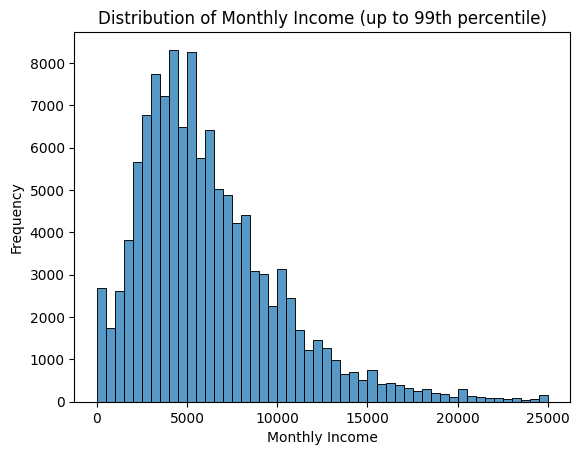

In [30]:
income_99 = df["MonthlyIncome"].quantile(0.99)

income_filtered = df.loc[
    df["MonthlyIncome"] <= income_99,
    "MonthlyIncome"
]

sns.histplot(income_filtered, bins=50)

plt.xlabel("Monthly Income")
plt.ylabel("Frequency")
plt.title("Distribution of Monthly Income (up to 99th percentile)")
plt.show()

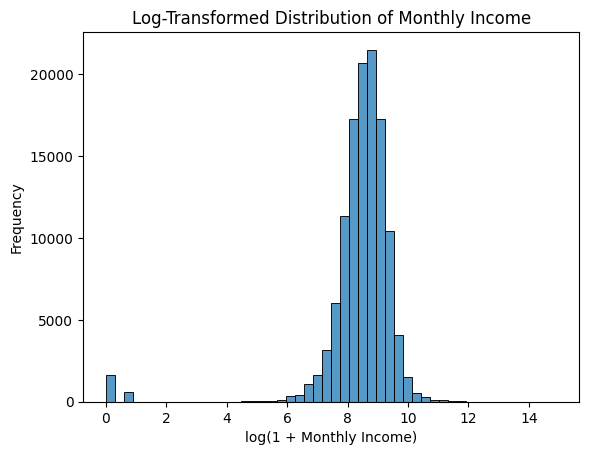

In [31]:
sns.histplot(np.log1p(df["MonthlyIncome"]), bins=50)

plt.xlabel("log(1 + Monthly Income)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Distribution of Monthly Income")
plt.show()

Here, we have carried out a log(1+x) transformation to compress the scale of the distribution, so as to adjust for outliers; we use (1+x) rather than x to account for zero income.
The log transformed variable is not as as skewed.

Now, we have established the following things-
- The number of missing values in the monthly income variable is too large for us to drop
- The missingness itself is not an indicator of financial distress
- The data is right skewed; imputation by median might be the best decision moving ahead
- On applying a logarithmic transformation, we see the the distribution is slightly more symmetrical; since we shall be using a Logistic Regression model, this transformation might prove to have a more useful relationship with the log odds (ln(p/1-p))

In [32]:
pd.crosstab(
    df["NumberOfDependents"].isna(),
    df["SeriousDlqin2yrs"],
    normalize="index"
)

SeriousDlqin2yrs,0,1
NumberOfDependents,,
False,0.932590,0.067410
True,0.954383,0.045617


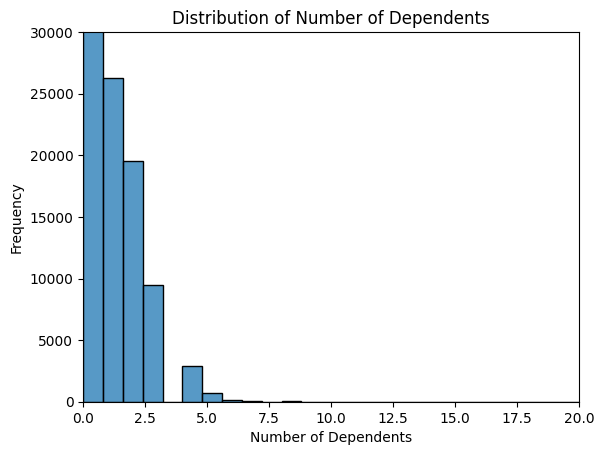

In [33]:
sns.histplot(df['NumberOfDependents'], bins= 25
             )
plt.xlim(0, 20)
plt.ylim(0, 30000)
plt.xlabel("Number of Dependents")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Dependents")
plt.show()

In [34]:
df['NumberOfDependents'].value_counts()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

In [35]:
print(df['NumberOfDependents'].agg(['mean', 'median', 'min', 'max', 'std']))
print(df['NumberOfDependents'].quantile([0.25, 0.5, 0.75, 0.99]))
print(df['NumberOfDependents'].mode()[0])

mean       0.757222
median     0.000000
min        0.000000
max       20.000000
std        1.115086
Name: NumberOfDependents, dtype: float64
0.25    0.0
0.50    0.0
0.75    1.0
0.99    4.0
Name: NumberOfDependents, dtype: float64
0.0


We have established that- 
- Missing values are not indicators of financial distress
- The number of missing values is small enough that we may choose to drop them; but imputation by mode (since the data is right skewed with extreme concentration at 0) might help us to prevent any information loss
- Another method to impute could be to fit a negative binomial distribution to the variable(since the variance exceeds the mean) and generate the missing values after estimating the rate parameter; although we should be cautious of data leakage

In [36]:
df['RevolvingUtilizationOfUnsecuredLines'].agg(['mean', 'median', 'min', 'max', 'std'])

mean          6.048438
median        0.154181
min           0.000000
max       50708.000000
std         249.755371
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [37]:
thresh = [1, 2, 5]

for t in thresh:
    prop = df[df['RevolvingUtilizationOfUnsecuredLines'] > t].shape[0] / df.shape[0]
    print(f"Proportion of records with RevolvingUtilizationOfUnsecuredLines > {t}: {prop:.4f}")

Proportion of records with RevolvingUtilizationOfUnsecuredLines > 1: 0.0221
Proportion of records with RevolvingUtilizationOfUnsecuredLines > 2: 0.0025
Proportion of records with RevolvingUtilizationOfUnsecuredLines > 5: 0.0017


In [38]:
df['DebtRatio'].agg(['mean', 'median', 'min', 'max', 'std'])

mean         353.005076
median         0.366508
min            0.000000
max       329664.000000
std         2037.818523
Name: DebtRatio, dtype: float64

In [39]:
df['DebtRatio'].describe(percentiles=[.25, .5, .75, .90, .95, .99, .995])

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
90%        1267.000000
95%        2449.000000
99%        4979.040000
99.5%      6186.010000
max      329664.000000
Name: DebtRatio, dtype: float64

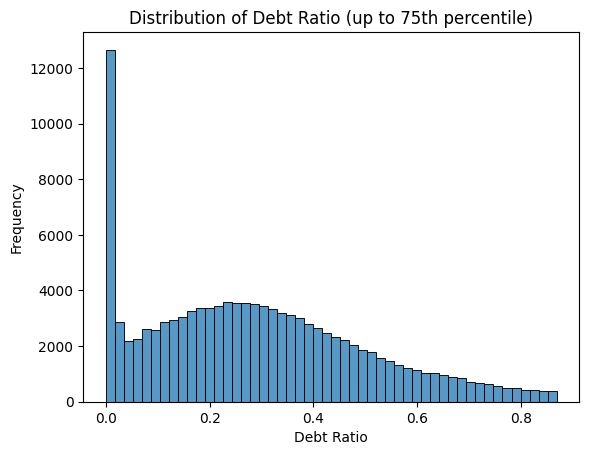

In [40]:
debt_75 = df['DebtRatio'].quantile(0.75)

sns.histplot(
    df.loc[df['DebtRatio'] <= debt_75, 'DebtRatio'],
    bins=50
)

plt.xlabel("Debt Ratio")
plt.ylabel("Frequency")
plt.title("Distribution of Debt Ratio (up to 75th percentile)")
plt.show()

When referring to individuals, the term 'Debt Ratio' actually is the 'Debt to Service Ratio'. This is the ratio of monthly total debt to the monthly gross income; by this definition it is highly unlikely that this quantity exceeds 1.

On further research, we found out that this has been a topic of discussion on the Kaggle 'Give Me Some Credit' forum; there seems to be very high association of debt ratio values exceeding 1 with the missing entries in the monthly income column. We shall investigate this further before commenting.

In [41]:
print((df['DebtRatio'] > 1).sum())
print((df['DebtRatio'] >1).mean())

35137
0.23424666666666666


In [42]:
pd.crosstab(
    df['DebtRatio'] > 1,
    df['MonthlyIncome'].isna(),
    normalize='index'
)

MonthlyIncome,False,True
DebtRatio,,
False,0.984094,0.015906
True,0.205851,0.794149


The association between debt ratios exceeding 1 and the missing monthly income values point to a data collection issue; our previous assessment regarding imputation with median for the missing values now changes. We may have to employ a different strategy altogether.

Let us explore the relationship of high values of revolving utilization ratio with other variables.

In [43]:
pd.crosstab(
    df['RevolvingUtilizationOfUnsecuredLines'] > 1,
    df['SeriousDlqin2yrs'],
    normalize='index'
)

SeriousDlqin2yrs,0,1
RevolvingUtilizationOfUnsecuredLines,,
False,0.940080,0.059920
True,0.627522,0.372478


This indicates dropping the outliers might not be the best move, since there is significant difference in proportion when we apply the filter.

In [44]:
pd.crosstab(
    df['RevolvingUtilizationOfUnsecuredLines'] > 1,
    df['DebtRatio'] > 1,
    normalize='index'
)

DebtRatio,False,True
RevolvingUtilizationOfUnsecuredLines,,
False,0.765365,0.234635
True,0.782897,0.217103


This is not as informative.

## Preliminary Data Quality Decisions

| Issue | Evidence | Decision | Justification |
|---|---|---|---|
| Missing MonthlyIncome | Missing entries not indicators of anything, have strong association with large values of debt ratio | Investigate data discrepancies further | Initially we thought imputation was the way to go, but the discovery we made regarding the association with the debt ratio needs to be studied |
| Missing NumberOfDependents | Relatively small number of missing values, right skewed distribution with mode 0 | Impute, method of imputation to be decided | Intuitively it is a variable that should be strongly related to the target, imputing allows us to avoid information loss |
| age = 0 | Singular entry under 18 | Drop | One entry in a large dataset, obviously invalid |
| Extreme MonthlyIncome | Boxplot, maximum | Keep as is | Large incomes in general are rare, nothing unusual about them being present in the data |
| Extreme RevolvingUtilization... | Very few values exceeding 1, 99th percentile is at 1.09, but increased proportion of serious delinquencies in cases of high ratio | Do not drop | Potential information loss on dropping the entries |
| Extreme DebtRatio | Associated with missing income entries | Investigate data discrepancies further | Same as for missing monthly income |

In [45]:
df.loc[
    (df['DebtRatio'] > 1) & (df['MonthlyIncome'].isna()),
    'DebtRatio'
].describe()

count     27904.000000
mean       1782.953985
std        4362.924654
min           2.000000
25%         279.750000
50%        1295.000000
75%        2478.000000
max      329664.000000
Name: DebtRatio, dtype: float64

In [46]:
df.loc[
    (df['DebtRatio'] > 1) & (df['MonthlyIncome'].notna()),
    'DebtRatio'
].describe()

count     7233.000000
mean       437.495836
std       1678.184932
min          1.000500
25%          1.217111
50%          1.748804
75%         47.000000
max      61106.500000
Name: DebtRatio, dtype: float64

In [47]:
print(
    "DebtRatio > 1 & income missing:",
    ((df['DebtRatio'] > 1) & df['MonthlyIncome'].isna()).sum()
)

print(
    "DebtRatio > 1 & income observed:",
    ((df['DebtRatio'] > 1) & df['MonthlyIncome'].notna()).sum()
)

DebtRatio > 1 & income missing: 27904
DebtRatio > 1 & income observed: 7233


- We can see that there are significantly more counts of the Debt Ratio exceeding 1 when the income is missing, as opposed to when it is observed
- When the monthly income is observed, only about 4.8% of the data has debt ratio exceeding 1
- This evidence is again pointing to a potential data quality issue

## 4. Exploratory Data Analysis

Now, we shall explore the distribution of the target, its individual relationship with all predictors, and potential relationships within the predictors themselves.

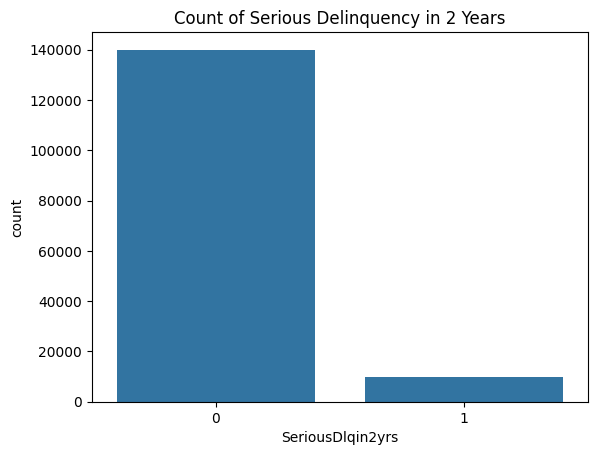

In [48]:
sns.countplot(x='SeriousDlqin2yrs', data=df)
plt.title("Count of Serious Delinquency in 2 Years")
plt.show()

The above graph highlights the massive class imbalance present in the target. Class imbalance will need to be accounted for when selecting evaluation metrics and determining the modelling strategy

Now, let us see how the predictors are distributed for different values of the target.

In [49]:
df[df['SeriousDlqin2yrs'] == 0].describe(percentiles=[.25, .5, .75, .90, .95, .99, .995])


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,139974.000000,139974.0,139974.000000,139974.000000,139974.000000,139974.000000,1.119120e+05,139974.000000,139974.000000,139974.000000,139974.000000,136229.000000
mean,74968.042429,0.0,6.168855,52.751375,0.280109,357.151168,6.747838e+03,8.493620,0.135225,1.020368,0.126666,0.743417
std,43297.906332,0.0,256.126350,14.791079,2.946075,2083.282060,1.481350e+04,5.105229,2.909088,1.105512,2.900930,1.105895
min,2.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37453.250000,0.0,0.026983,42.000000,0.000000,0.173707,3.461000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,74982.500000,0.0,0.133288,52.000000,0.000000,0.362659,5.466000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112464.750000,0.0,0.487686,63.000000,0.000000,0.865608,8.333000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
90%,134937.700000,0.0,0.933841,73.000000,1.000000,1301.000000,1.175290e+04,15.000000,0.000000,2.000000,0.000000,2.000000
95%,142460.350000,0.0,1.000000,78.000000,1.000000,2468.000000,1.475090e+04,18.000000,0.000000,3.000000,0.000000,3.000000
99%,148486.270000,0.0,1.026391,87.000000,3.000000,4966.000000,2.500000e+04,24.000000,1.000000,4.000000,1.000000,4.000000


In [50]:
df[df['SeriousDlqin2yrs'] == 1].describe(percentiles=[.25, .5, .75, .90, .95, .99, .995])

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,10026.000000,10026.0,10026.000000,10026.000000,10026.00000,10026.000000,8357.000000,10026.000000,10026.000000,10026.000000,10026.000000,9847.000000
mean,75453.643427,1.0,4.367282,45.926591,2.38849,295.121066,5630.826493,7.882306,2.091362,0.988530,1.828047,0.948208
std,43349.986634,0.0,131.835778,12.916289,11.73451,1238.360283,6171.719674,5.653601,11.762760,1.425723,11.753068,1.219367
min,1.000000,1.0,0.000000,21.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,38257.250000,1.0,0.398219,36.000000,0.00000,0.193979,2963.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,75283.000000,1.0,0.838853,45.000000,0.00000,0.428227,4500.000000,7.000000,0.000000,1.000000,0.000000,0.000000
75%,112962.000000,1.0,1.000000,54.000000,2.00000,0.892371,6800.000000,11.000000,1.000000,2.000000,1.000000,2.000000
90%,135898.500000,1.0,1.018153,63.000000,3.00000,633.000000,10000.000000,15.000000,2.000000,2.000000,1.000000,3.000000
95%,142975.750000,1.0,1.121264,68.000000,4.00000,2056.750000,12709.400000,18.000000,4.000000,3.000000,2.000000,3.000000
99%,148684.250000,1.0,1.715092,80.000000,98.00000,5226.500000,22672.760000,25.000000,98.000000,6.000000,98.000000,4.540000


Since the distributions may be skewed, and the number of observations is vastly different in the two cases, we shall compare medians for now:

| Variable | No serious delinquency — Median | Serious delinquency — Median |
|---|---:|---:|
| RevolvingUtilizationOfUnsecuredLines | 0.13 | 0.83 |
| age | 52 | 45 |
| NumberOfTime30-59DaysPastDueNotWorse | 0 | 0 |
| DebtRatio | 0.36 | 0.42 |
| MonthlyIncome | 5466 | 4500 |
| NumberOfOpenCreditLinesAndLoans | 8 | 7 |
| NumberOfTimes90DaysLate | 0 | 0 |
| NumberRealEstateLoansOrLines | 1 | 1 |
| NumberOfTime60-89DaysPastDueNotWorse | 0 | 0 |
| NumberOfDependents | 0 | 0 |

From comparing the medians, a marked shift is only observed in the following variables:
- RevolvingUtilizationOfUnsecuredLines
- Age
- DebtRatio (not that large)
- MonthlyIncome


We may have to compare other statistics since this is not providing us a very a clear indication of the change in distributions. We would especially expect variables indicating the number of times the accounts have been due for more than a certain duration of time to show some change when we consider the data points corresponding to serious delinquencies.

Let us compare means now

| Variable | No serious delinquency — Mean | Serious delinquency — Meam |
|---|---:|---:|
| RevolvingUtilizationOfUnsecuredLines | 6.17 | 4.37 |
| age | 52.75 | 42.96 |
| NumberOfTime30-59DaysPastDueNotWorse | 0.28 | 2.38 |
| DebtRatio | 357.15  | 295.12 |
| MonthlyIncome | 6747 | 5630 |
| NumberOfOpenCreditLinesAndLoans | 8.49 | 7.88 |
| NumberOfTimes90DaysLate | 0.14 | 2.09 |
| NumberRealEstateLoansOrLines | 1.02 | 0.98 |
| NumberOfTime60-89DaysPastDueNotWorse | 0.13 |1.83 |
| NumberOfDependents | 0.74 | 0.95 |

Although differences in means can provide some indication of association, they should be interpreted cautiously because they are sensitive to extreme observations and do not describe the full distribution.

In [51]:
df[df['NumberOfTime30-59DaysPastDueNotWorse'] == 98].shape[0]

264

In [52]:
df[df['NumberOfTime60-89DaysPastDueNotWorse'] == 98].shape[0]

264

In [53]:
df[df['NumberOfTimes90DaysLate'] == 98].shape[0]

264

In [54]:
df[(df['SeriousDlqin2yrs'] == 0) & (df['NumberOfTimes90DaysLate'] == 98)].shape[0]

121

In [55]:
df.loc[df['SeriousDlqin2yrs'] == 0, 'NumberOfTimes90DaysLate'].value_counts()

NumberOfTimes90DaysLate
0     135108
1       3478
2        779
3        282
98       121
4         96
5         48
6         32
7          7
8          6
9          5
10         3
11         2
15         2
13         2
14         1
96         1
12         1
Name: count, dtype: int64

In [56]:
df.loc[df['SeriousDlqin2yrs'] == 1, 'NumberOfTimes90DaysLate'].value_counts()

NumberOfTimes90DaysLate
0     6554
1     1765
2      776
3      385
4      195
98     143
5       83
6       48
7       31
8       15
9       14
10       5
96       4
11       3
13       2
17       1
14       1
12       1
Name: count, dtype: int64

Now here, we can see another potential data quality issue. 
- How can an account being 90 days or worse due be classified as not a delinquency?
- How can the values of the variable jump from 17 to 96 and 98? How are there no values lying in between?


Intuitively, we know that these three variables are bound to be correlated with each other. In addition, they seem to have certain impossible values. We will have to decide a plan of action to tackle these issues, before we get to the model training. 

In [57]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [58]:
df.dtypes

Unnamed: 0                                int64
SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [59]:
int_cols=[]
for i in df.columns:
    if df[i].dtypes == 'int64':
        int_cols.append(i)

int_cols

['Unnamed: 0',
 'SeriousDlqin2yrs',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse']

In [60]:
int_cols.pop(0)
int_cols

['SeriousDlqin2yrs',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse']

In [61]:
int_cols.append('NumberOfDependents')

In [62]:
float_cols=[]
for i in df.columns:
    if i not in int_cols:
        float_cols.append(i)

float_cols

['Unnamed: 0',
 'RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio',
 'MonthlyIncome']

In [63]:
float_cols.pop(0)


'Unnamed: 0'

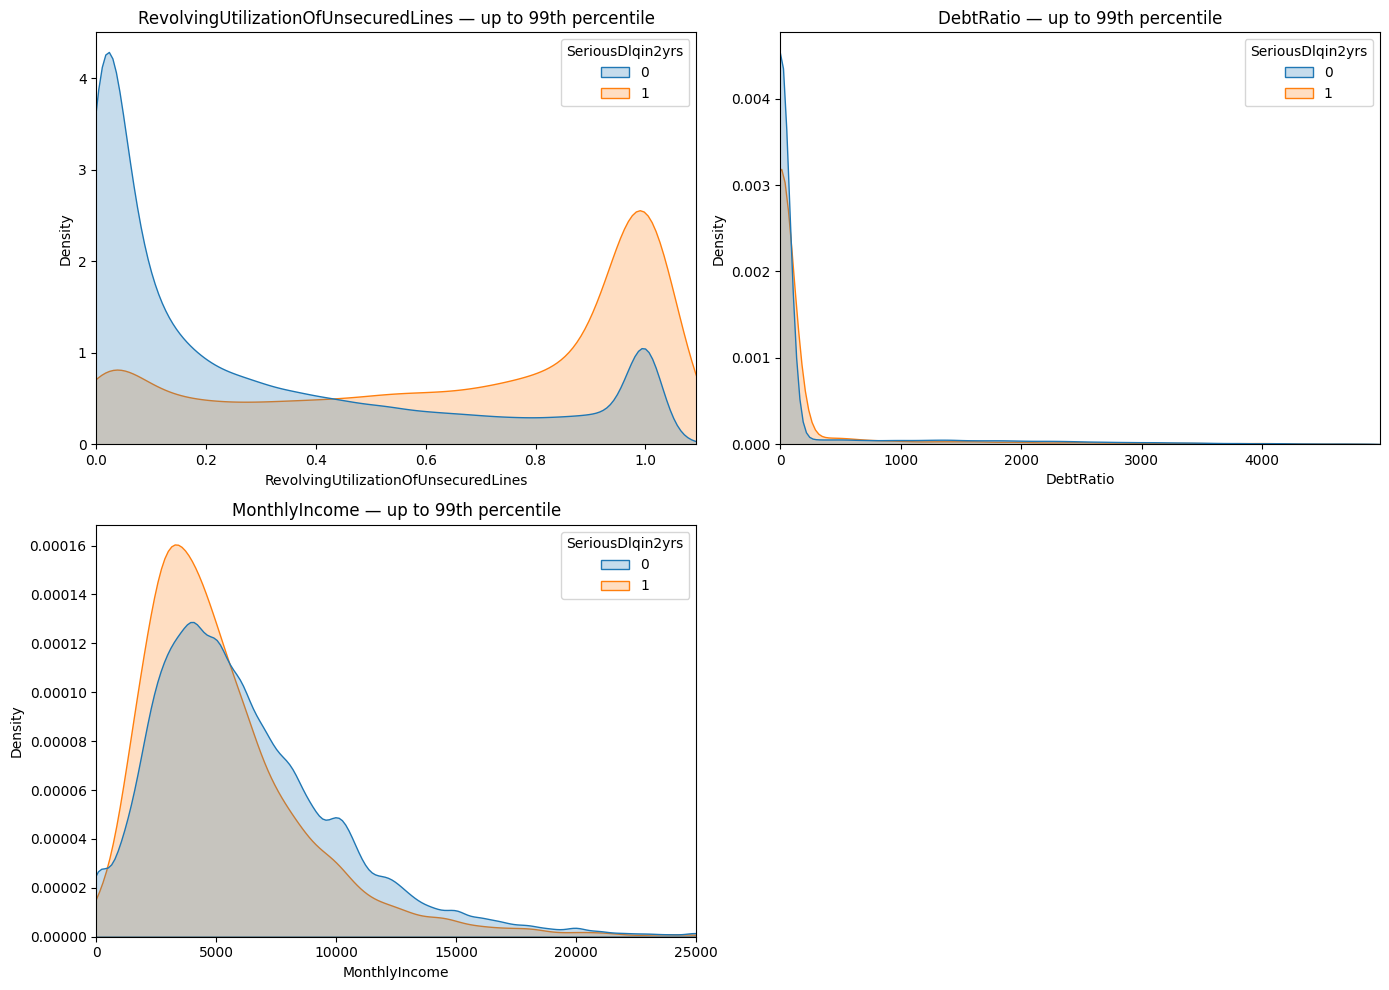

In [64]:
import math

n_cols = 2
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(14, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(float_cols):

    # 99th percentile
    upper = df[col].quantile(0.99)

    # Data used ONLY for visualization
    plot_data = df.loc[df[col] <= upper, [col, 'SeriousDlqin2yrs']].dropna()

    sns.kdeplot(
        data=plot_data,
        x=col,
        hue='SeriousDlqin2yrs',
        fill=True,
        common_norm=False,
        ax=axes[i]
    )

    axes[i].set_xlim(0, upper)

    axes[i].set_title(f'{col} — up to 99th percentile')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')


# Remove unused axes
for i in range(len(float_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

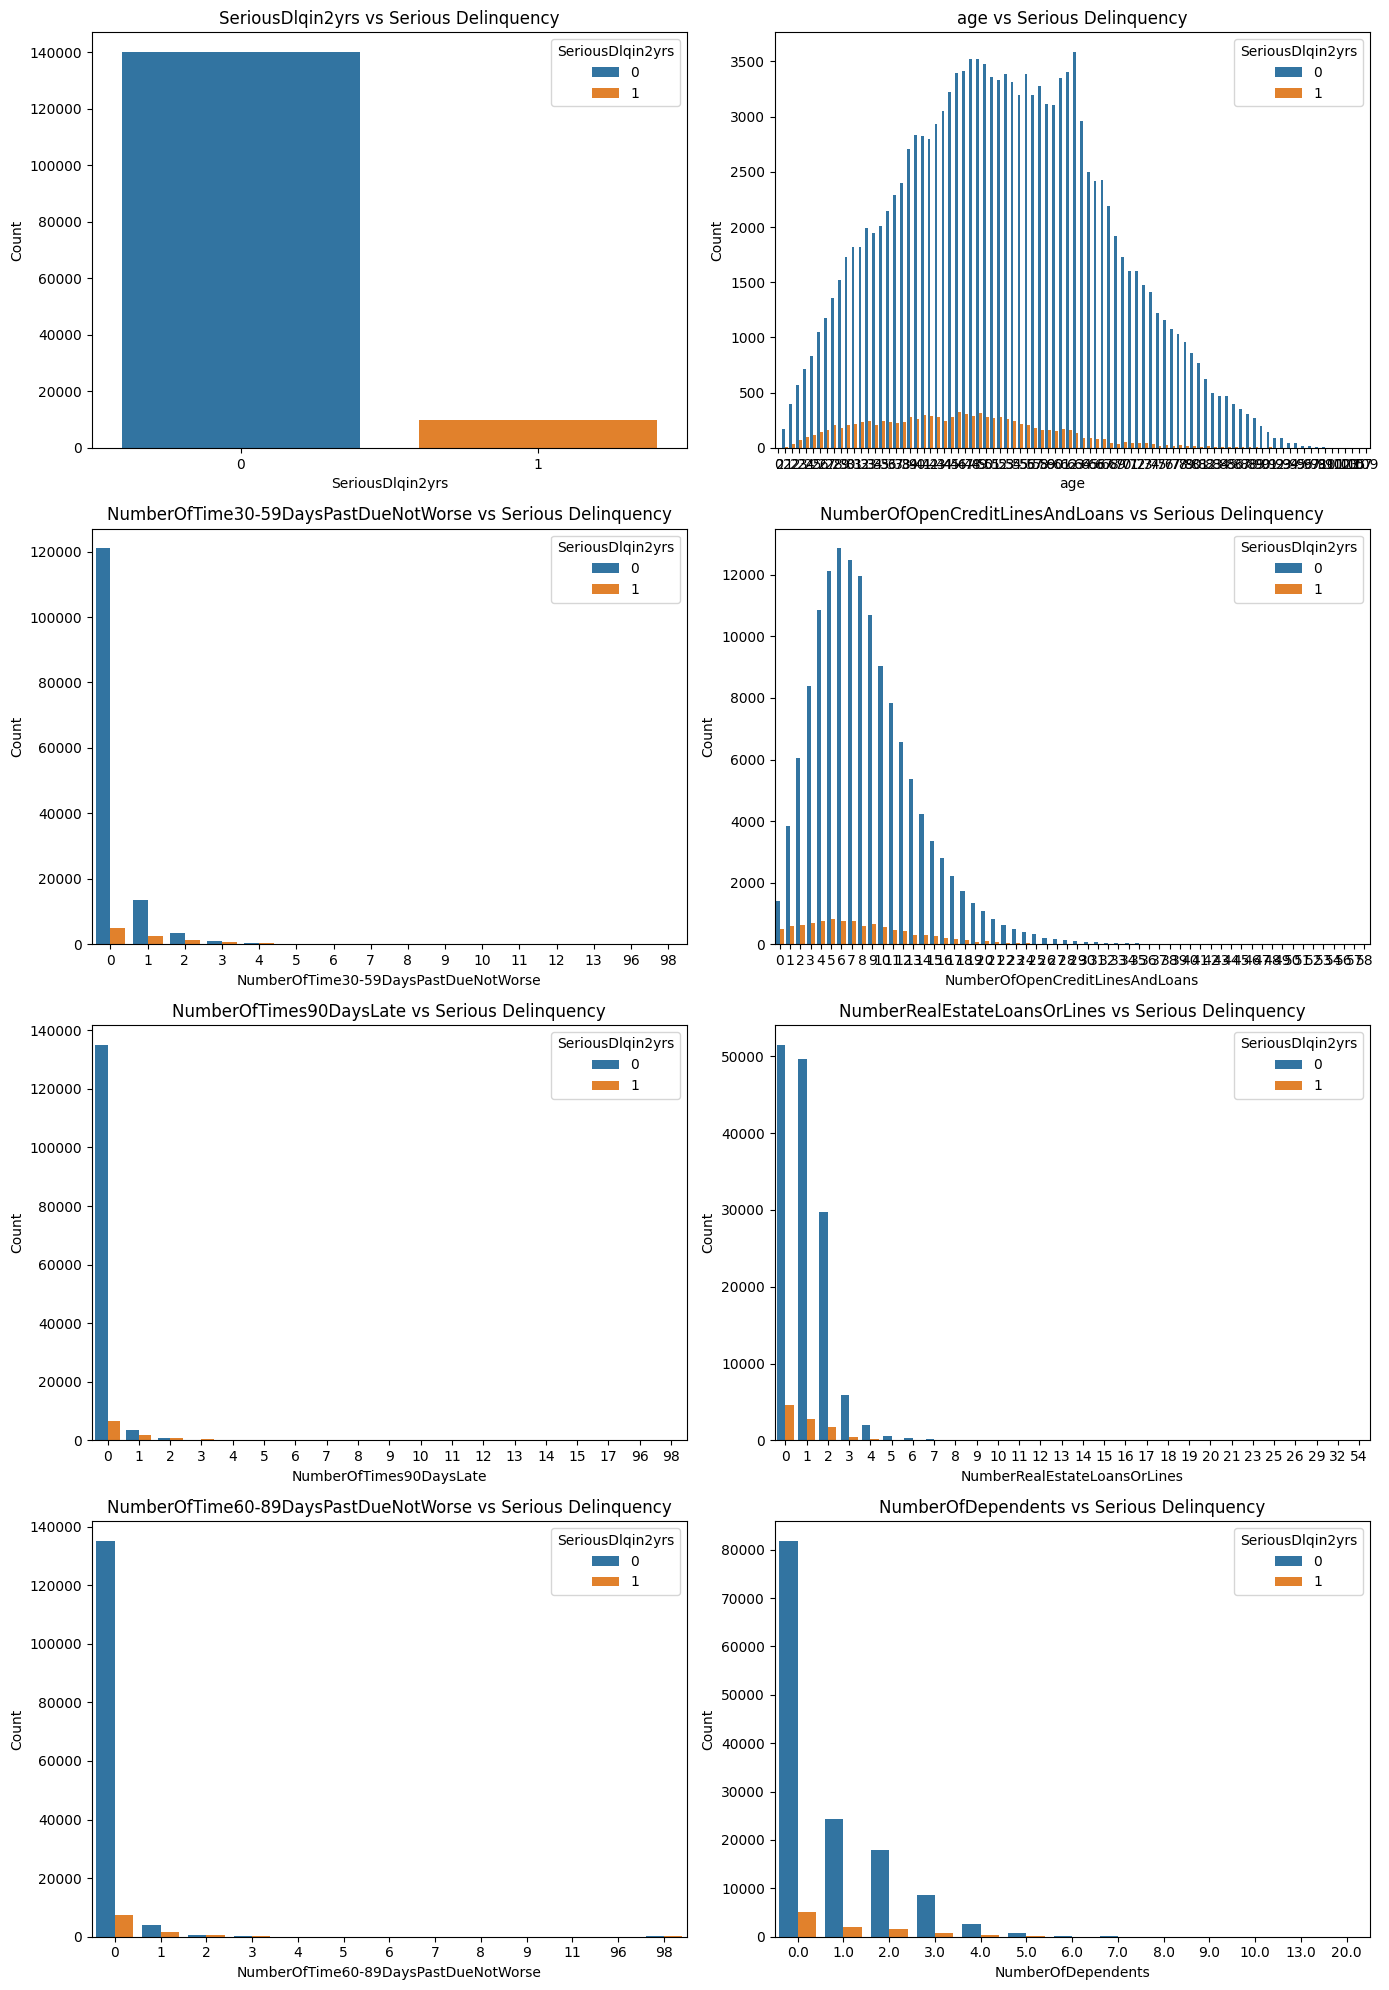

In [65]:
n_cols = 2
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):

    # 99th percentile
    upper = df[col].quantile(0.99)

    # Data used ONLY for visualization

    sns.countplot(
        data=df,
        x=col,
        hue='SeriousDlqin2yrs',
        ax=axes[i]
    )
    
    axes[i].set_title(f'{col} vs Serious Delinquency')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove unused subplots
for i in range(len(int_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Inspecting Linearity of predictors

In Logistic Regression, the log-odds of the outcome are assumed to have a linear relationship with the predictors. We therefore examine how the observed delinquency rate changes across different values or groups of each predictor. This provides an initial indication of potential nonlinearities, which we will investigate more formally during model development

In [66]:
df['IncomeDecile'] = pd.qcut(
    df['MonthlyIncome'],
    q=10,
    duplicates='drop'
)

income_risk = df.groupby(
    'IncomeDecile',
    observed=True
)['SeriousDlqin2yrs'].mean()

print(income_risk)

IncomeDecile
(-0.001, 2005.0]        0.084386
(2005.0, 3000.0]        0.096661
(3000.0, 3800.0]        0.091150
(3800.0, 4544.2]        0.080926
(4544.2, 5400.0]        0.073319
(5400.0, 6300.0]        0.066835
(6300.0, 7500.0]        0.059266
(7500.0, 9083.0]        0.051138
(9083.0, 11666.0]       0.045169
(11666.0, 3008750.0]    0.044920
Name: SeriousDlqin2yrs, dtype: float64


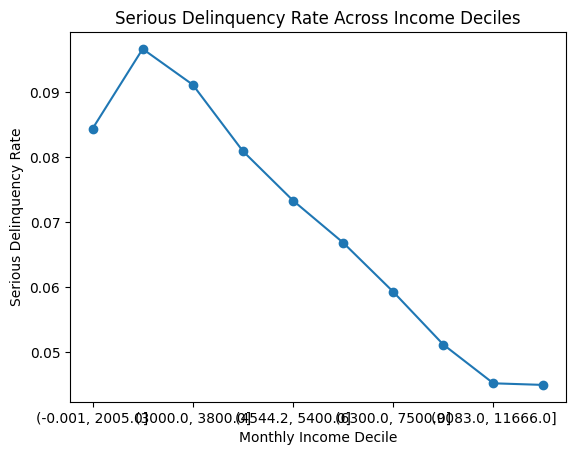

In [67]:
income_risk.plot(marker='o')

plt.xlabel('Monthly Income Decile')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate Across Income Deciles')
plt.show()

Delinquency rates decrease substantially across the lower income groups before flattening at higher income levels, suggesting that the relationship may not be strictly linear.

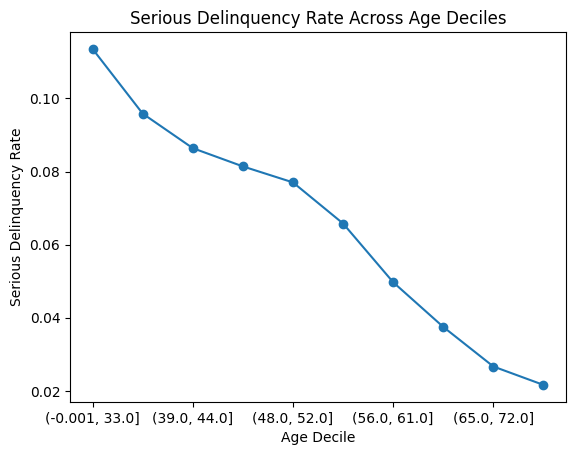

In [68]:
df['AgeGroup'] = pd.qcut(df['age'], q=10, duplicates='drop')

age_risk = df.groupby('AgeGroup', observed=True)['SeriousDlqin2yrs'].mean()

age_risk.plot(marker='o')

plt.xlabel('Age Decile')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate Across Age Deciles')
plt.show()

The delinquency rate appears to decrease approximately monotonically with age. The relationship does not show an obvious threshold or reversal, although this plot alone is insufficient to establish linearity in the log-odds.

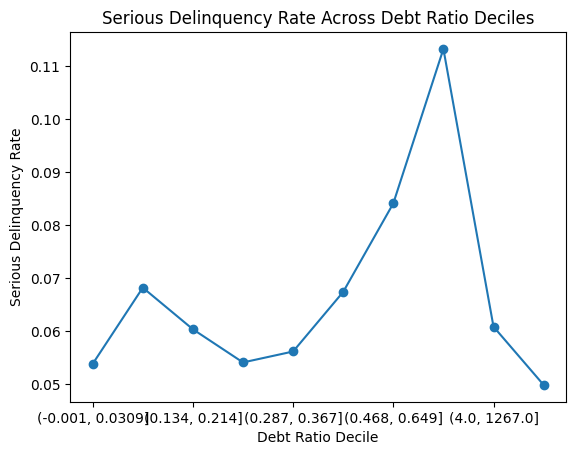

In [69]:
df['DebtRatioDecile'] = pd.qcut(df['DebtRatio'], q=10, duplicates='drop')

debt_risk = df.groupby('DebtRatioDecile', observed=True)['SeriousDlqin2yrs'].mean()

debt_risk.plot(marker='o')

plt.xlabel('Debt Ratio Decile')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate Across Debt Ratio Deciles')
plt.show()

The apparent nonlinearity may partly reflect the extreme right tail of DebtRatio and should be investigated after addressing the data-quality issue.

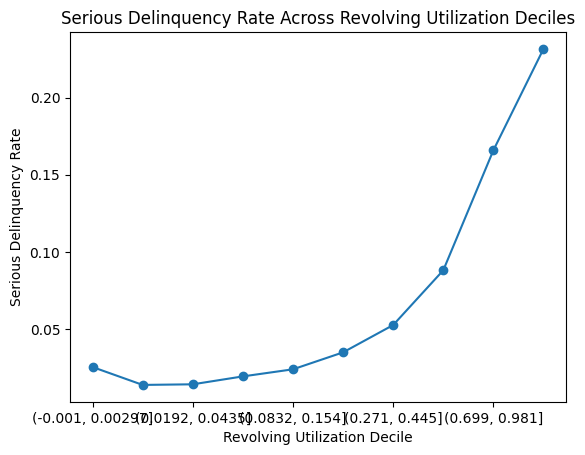

In [70]:
df['UtilizationGroup'] = pd.qcut(
    df['RevolvingUtilizationOfUnsecuredLines'],
    q=10,
    duplicates='drop'
)

util_risk = df.groupby(
    'UtilizationGroup',
    observed=True
)['SeriousDlqin2yrs'].mean()

util_risk.plot(marker='o')

plt.xlabel('Revolving Utilization Decile')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate Across Revolving Utilization Deciles')
plt.show()

The delinquency rate appears to increase across utilization deciles, with some curvature. The relationship appears broadly monotonic, but whether a linear specification is adequate should be evaluated during modelling.

Even though we have discovered some issues with the variables that count the number of instances an account was a certain time duration past due, we shall still plot their distribution to check whether they are linearly associated with our predictor.

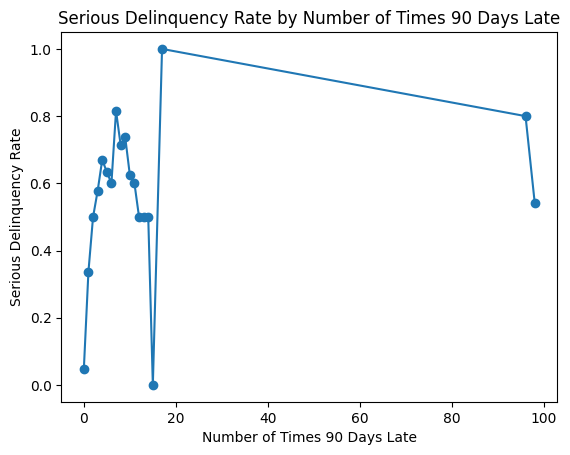

In [71]:
risk_90 = df.groupby(
    'NumberOfTimes90DaysLate'
)['SeriousDlqin2yrs'].mean()

risk_90.plot(marker='o')

plt.xlabel('Number of Times 90 Days Late')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate by Number of Times 90 Days Late')
plt.show()

This graph further validates our doubts regarding the quality of the data particularly in these variables.

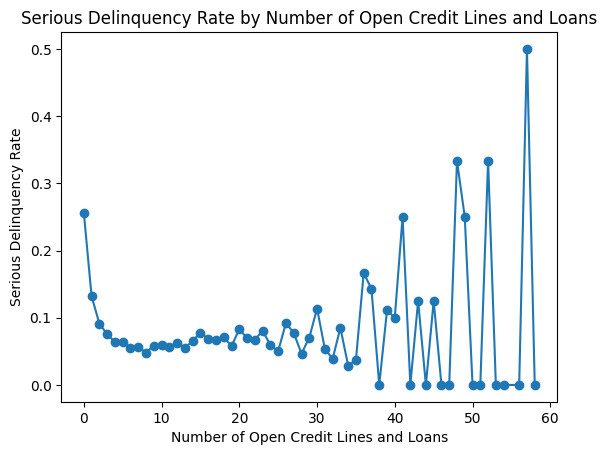

In [72]:
risk_opencredit = df.groupby(
    'NumberOfOpenCreditLinesAndLoans')['SeriousDlqin2yrs'].mean()

risk_opencredit.plot(marker='o')

plt.xlabel('Number of Open Credit Lines and Loans')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate by Number of Open Credit Lines and Loans')
plt.show()

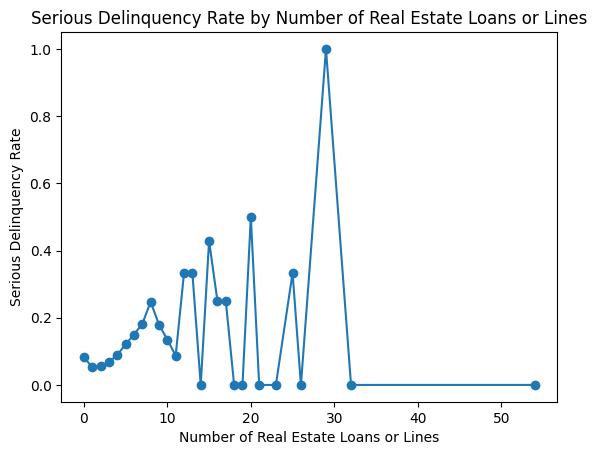

In [73]:
risk_securedcredit = df.groupby(
    'NumberRealEstateLoansOrLines')['SeriousDlqin2yrs'].mean()

risk_securedcredit.plot(marker='o')
plt.xlabel('Number of Real Estate Loans or Lines')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate by Number of Real Estate Loans or Lines')
plt.show()

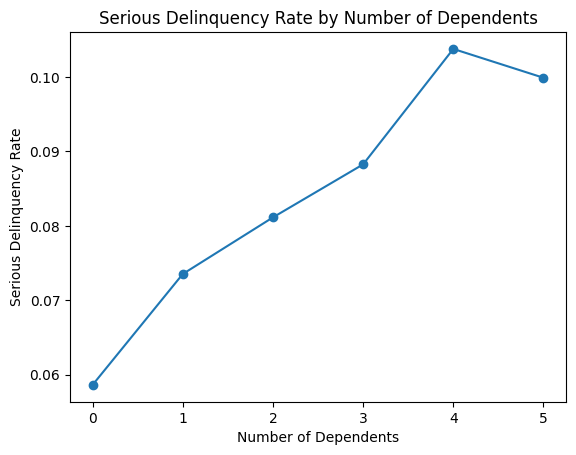

In [74]:

df['DependentsGrouped'] = df['NumberOfDependents'].clip(upper=5)
risk_dependents = df.groupby('DependentsGrouped')['SeriousDlqin2yrs'].mean()
risk_dependents.plot(marker='o')   

plt.xlabel('Number of Dependents')
plt.ylabel('Serious Delinquency Rate')
plt.title('Serious Delinquency Rate by Number of Dependents')
plt.show()

After ignoring some extreme (and potentially unlikely) extreme values, the relationship between the the number of dependents and the delinquency rate seems to be monotonic; but as for previous variables, this alone is not evidence of linearity.

Let us explore the outliers in the number of dependents a little further.

In [75]:
df['NumberOfDependents'].value_counts()

NumberOfDependents
0.0     86902
1.0     26316
2.0     19522
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
10.0        5
9.0         5
20.0        1
13.0        1
Name: count, dtype: int64

In [76]:
df['NumberOfDependents'].quantile([0.25, 0.5, 0.75, 0.99])

0.25    0.0
0.50    0.0
0.75    1.0
0.99    4.0
Name: NumberOfDependents, dtype: float64

In [77]:
df[df['NumberOfDependents'] > 4].shape[0]

991

There are very few observations greater than 4; we may even select a threshold such as 6, since 5 and 6 do account for nearly 800 observations (which is still an insignificant quantity in context of the total entries in the data); but above that, the values may be discounted.

## Hypothesis Review

| Variable | Initial Hypothesis | Evidence from EDA | Strength of Association | Functional form |
|---|---|---|---| --- |
| RevolvingUtilizationOfUnsecuredLines | Strong | Large difference in median, slightly curved graph, large difference in density plots | Strong | Monotonic, linearity uncertain |
| age | Moderate, Non-Linear | Difference in mean and median, downward sloping graph | Strong | Monotonic association, potential non-linearity |
| NumberOfTime30-59DaysPastDueNotWorse | Strong | Issue with data quality, irregularly curved graph | Further investigation needed | -- |
| DebtRatio | Strong | Slight difference in median, mean incomparable due to outliers, non-linear graph, no obvious difference in density plots | Weak (Needs more deliberation) | Potential non-linearity |
| MonthlyIncome | Moderate | Large difference in mean and median, somewhat monotonic graph, density plots show a marked shift | Strong | Monotonic, potentially linear |
| NumberOfOpenCreditLinesAndLoans | Moderate | Median and means not very different when target is 0 and 1; shape of countplots not very different, even though scale is vastly different due to class imbalance | Weak | Functional form unclear
| NumberOfTimes90DaysLate | Strong | Data quality issue | Further investigation needed | -- |
| NumberRealEstateLoansOrLines | Moderate | No difference in mean and median when target is present and absent, respecitvely, irregularly shaped graph | Weak | Potential non-linearity |
| NumberOfTime60-89DaysPastDueNotWorse | Strong | Data quality issue | Further investigation needed | -- |
| NumberOfDependents | Strong | Little to no difference in mean, median whether target is present or not, shapes of countplots are similar, graph is not linear | Weak | Potential non-linearity |

## 4. Exploratory Data Analysis — Distribution Checks

We shall now deliberate upon on strategies to handle missingness, outliers and multicollinearity

In [78]:
df.isnull().mean()*100

Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
IncomeDecile                            19.820667
AgeGroup                                 0.000000
DebtRatioDecile                          0.000000
UtilizationGroup                         0.000000
DependentsGrouped                        2.616000
dtype: float64

In [79]:
df.drop(columns=['IncomeDecile', 'AgeGroup', 'DebtRatioDecile', 'UtilizationGroup', 'DependentsGrouped'], inplace=True)
df.isnull().mean()*100

Unnamed: 0                               0.000000
SeriousDlqin2yrs                         0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
age                                      0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
DebtRatio                                0.000000
MonthlyIncome                           19.820667
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
NumberOfDependents                       2.616000
dtype: float64

We have previously seen that for both the variables with missing entries; the missingness itself is not associated with the target. We compared the proportion of positives for the overall data to that of only the missing values, and found out that the proportion, in case of both variables, were in fact lower when only missing entries were considered.

After observing the distributions of both these variables, we may implement the following startegies to deal with the missingness - 

| Variable | Missing % | Missingness associated with Target? | Proposed Treatment | Justificiation |
| --- | --- | --- | --- | --- |
| MonthlyIncome | 19.82 | No | Imputation with Median + Missingness Indicator | Distribution is right skewed, so median is appropriate choice of statistic; indicator allows us to preserve information |
| NumberOfDependents | 2.616 | No | Imputation with Mode | Distribution is right skewed with heavy concentration around 0 |


Let us now explore the extreme values in the delinquency variables.

In [80]:
delinq_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

In [81]:
for col in delinq_cols:
    print(col)
    print(df[df[col].isin([96, 98])].shape[0])

NumberOfTime30-59DaysPastDueNotWorse
269
NumberOfTime60-89DaysPastDueNotWorse
269
NumberOfTimes90DaysLate
269


In [82]:
df[df[delinq_cols].isin([96, 98]).any(axis=1)][delinq_cols]

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
1733,98,98,98
2286,98,98,98
3884,98,98,98
4417,98,98,98
4705,98,98,98
...,...,...,...
147774,98,98,98
149153,98,98,98
149239,98,98,98
149439,98,98,98


In [83]:
df[df[delinq_cols].isin([96]).any(axis=1)][delinq_cols]

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
41944,96,96,96
69478,96,96,96
84167,96,96,96
94106,96,96,96
120049,96,96,96


There seems to be an almost complete overlap in all three columns whenever either of these values occur. Let us now explore how the proportion of positives changes when only considering these extreme values. Since we have established the overlap, we may now only look at one of the columns instead of looking at all three.

In [84]:
pd.crosstab(
    df['NumberOfTimes90DaysLate'].isin([96, 98]),
    df['SeriousDlqin2yrs'],
    normalize='index'
)

SeriousDlqin2yrs,0,1
NumberOfTimes90DaysLate,,
False,0.934022,0.065978
True,0.453532,0.546468


In [85]:
df['SuspiciousDelinqValue'] = (
    df[delinq_cols].isin([96, 98]).any(axis=1)
).astype(int)

df.groupby('SuspiciousDelinqValue')['SeriousDlqin2yrs'].agg(
    ['count', 'mean']
)

,count,mean
SuspiciousDelinqValue,,
0,149731,0.065978
1,269,0.546468


Proportion of positives increases significantly when we only consider the entries with extreme values of number of delinquencies; although it is remarkable that for nearly 45 percent of the cases (when only extreme values are considered) are not positives. There are only 269 such entries, so it is very tempting to drop these rows, since even if we consider 96, 98 as special values or create bins and store all these values in the highest bin; there is no explanation to how 45 percent of the times that these values are observed are marked as negatives. Dropping any entries is a drastic measure, so however tempting it is, for now we shall declare suspicious values as NaNs, while creating an indicator for such suspicious values.

Let us explore the outliers in DebtRatio; we have previously observed that there seems to be some association between these extreme values and the missing values in the monthly income column. If and when we impute the missing values in the monthly income column, this numerical association goes away. Hence, let us first create the missingness indicator column that we spoke about above, and explore the relationship of this indicator with the extreme values further.

In [86]:
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isna().astype(int)

In [87]:
df.groupby('MonthlyIncome_missing')['DebtRatio'].describe(percentiles=[.25, .5, .75, .90, .95, .99, .995])

,count,mean,std,min,25%,50%,75%,90%,95%,99%,99.5%,max
MonthlyIncome_missing,,,,,,,,,,,,
0,120269.0,26.598777,424.446457,0.0,0.143388,0.296023,0.482559,0.763149,1.128771,661.82,1781.83,61106.5
1,29731.0,1673.396556,4248.372895,0.0,123.000000,1159.000000,2382.000000,3785.000000,4902.500000,8084.50,10220.10,329664.0


There seem to be certain extreme values even when the monthly income is present; although these lie above the 95th percentile. When it is missing, right from the 25th percentile, we start observing unlikely values of DebtRatio. The missingness indicator will allow us to preserve this valuable piece of information, although we will probably still have to apply a log transfornation to compress the scale of the distribution of DebtRatio.

For outliers, we may take the following measures-

| Variable | Extreme Values Observed | Potential Explanation | Proposed Treatment |
|---|---|---|---|
| DebtRatio | Yes | Related to missing values in Monthly Income column | log(1+x) transformation, missingness indicator for monthly income |
| RevolvingUtilizationOfUnsecuredLines | Yes | Data quality issue, but association with positives is present for outliers | log(1+x) transformation |
| MonthlyIncome | Yes | Genuine but extreme values | log(1+x) transformation |
| Delinquency variables | Yes | Data quality issue | Replace with NaNs and create indicator for suspicious values |

Let us explore the variables that we want to transform a little further, after which we will again comment on the proposed treatment.

In [88]:
float_cols

['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

In [89]:
df[float_cols].skew()

RevolvingUtilizationOfUnsecuredLines     97.631574
DebtRatio                                95.157793
MonthlyIncome                           114.040318
dtype: float64

Let us see how the shape of the distribution changes before and after applying the log(1 + x) transformation-

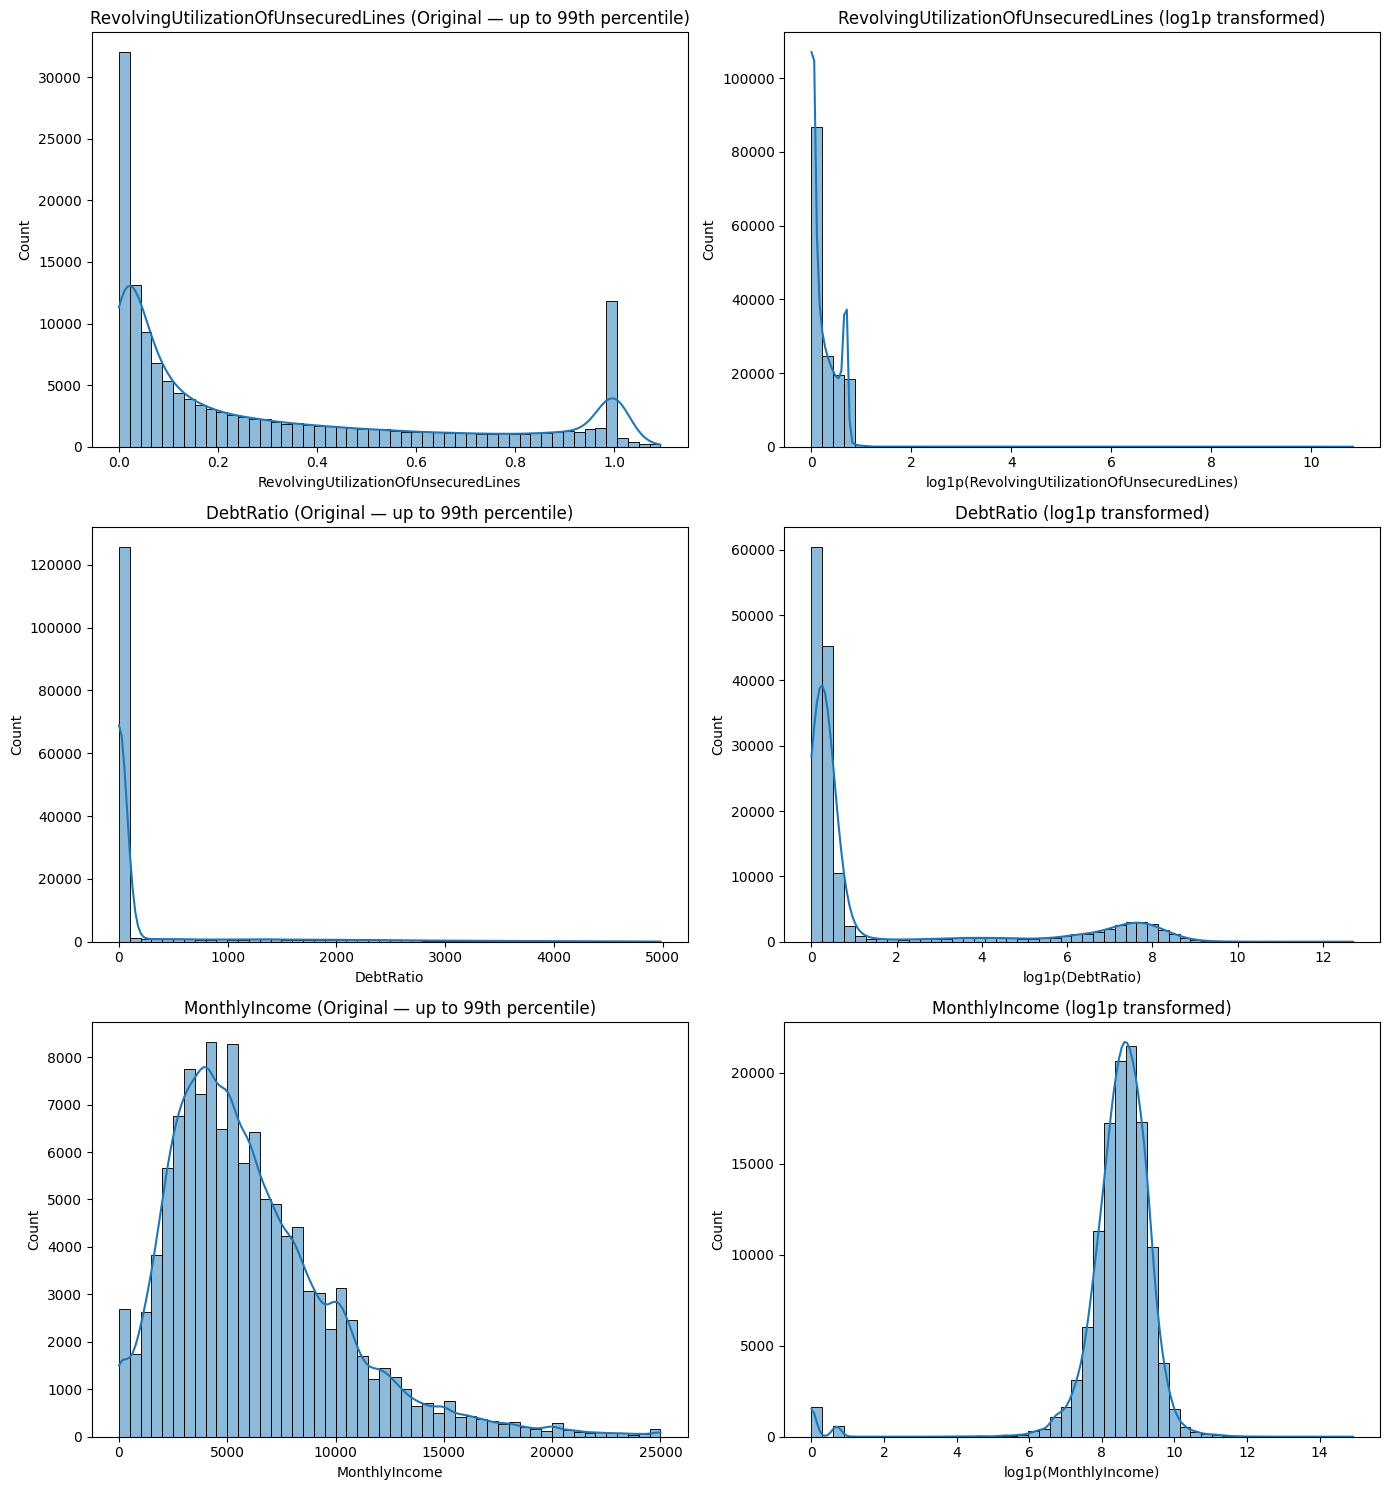

In [90]:
fig, axes = plt.subplots(
    nrows=len(float_cols),
    ncols=2,
    figsize=(14, 5 * len(float_cols))
)

for i, col in enumerate(float_cols):
    
    # -------------------------
    # Original distribution
    # -------------------------
    
    # Calculate 99th percentile
    upper = df[col].quantile(0.99)
    
    # Keep values only up to 99th percentile for visualization
    original_data = df.loc[
        (df[col].notna()) & (df[col] <= upper),
        col
    ]
    
    sns.histplot(
        original_data,
        bins=50,
        kde=True,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(
        f'{col} (Original — up to 99th percentile)'
    )
    axes[i, 0].set_xlabel(col)
    
    
    # -------------------------
    # Log1p transformed distribution
    # -------------------------
    
    log_data = np.log1p(
        df.loc[df[col].notna(), col]
    )
    
    sns.histplot(
        log_data,
        bins=50,
        kde=True,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(
        f'{col} (log1p transformed)'
    )
    axes[i, 1].set_xlabel(f'log1p({col})')


plt.tight_layout()
plt.show()

The log transformation substantially compresses the extreme right tail while preserving the ordering of observations. Its usefulness for model fit and linearity in the log-odds will be evaluated during modelling. Also it should be noted that for the raw data we are only considering data upto the 99th percentile in order to make sure that the histograms are interpretable; the log transformation takes care of the outliers, allowing us to plot over the entire range of values without making the graph appear unusual.

Let us now explore multicollinearity. We must keep in mind that this is a preliminary exploratiom; as VIF values might change drastically once we have preprocessed our data.

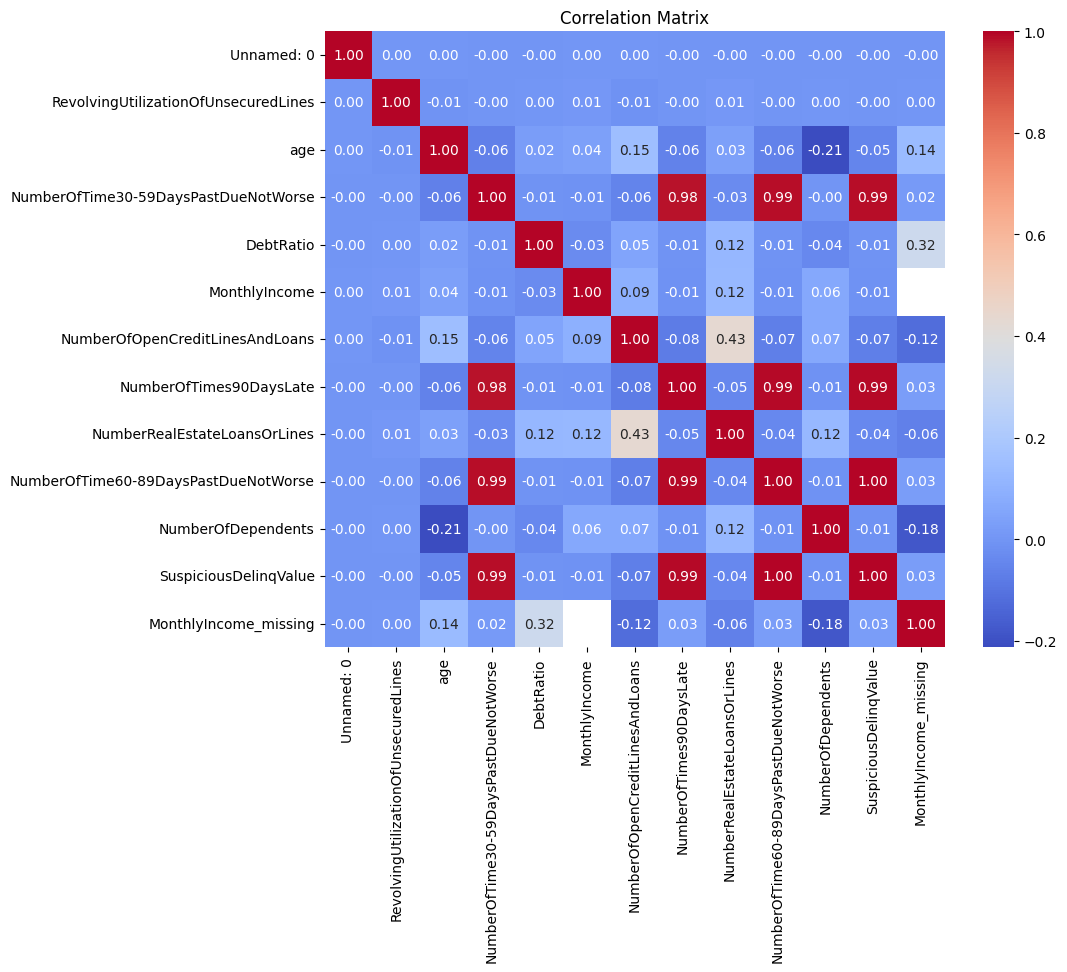

In [91]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.drop(columns='SeriousDlqin2yrs').corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()

- Very high correlation in the Delinquency variables
- Positive significant correlation present in NumberRealEstateLoansOrLines and NumberOfOpenCreditLinesAndLoans
- Some correlation also present between our income missingness indicator and DebtRatio
- Negative correlation present in NumberOfDependents and age

These are all correlations that can be logically explained.

Correlation only measures numeric association. To properly examine multicollinearity, we must calculate the Variance Inflation Factor (VIF).

In [92]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [93]:
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'SuspiciousDelinqValue', 'MonthlyIncome_missing'],
      dtype='object')

In [94]:
X_vif = df.drop(
    columns=['Unnamed: 0', 'SeriousDlqin2yrs']
)

In [95]:
## temporary imputation for calculation VIF since VIF cannot handle missing values
X_vif = X_vif.fillna(X_vif.median())

In [96]:
vif_data = pd.DataFrame()

vif_data['Variable'] = X_vif.columns

vif_data['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data

,Variable,VIF
0,RevolvingUtilizationOfUnsecuredLines,1.000781
1,age,4.297177
2,NumberOfTime30-59DaysPastDueNotWorse,41.614583
3,DebtRatio,1.178721
4,MonthlyIncome,1.269719
5,NumberOfOpenCreditLinesAndLoans,4.618604
6,NumberOfTimes90DaysLate,83.239436
7,NumberRealEstateLoansOrLines,2.306829
8,NumberOfTime60-89DaysPastDueNotWorse,186.731280
9,NumberOfDependents,1.440018


Usually, VIF > 5 is considered a marker of serious multicollinearity. In our data, only the delinquency variables seem to have serious multicollinearity present, which is understandable since all these three columns are related to each other.

Multicollinearity is primarily a concern in this project because Logistic Regression coefficients will be interpreted to understand the relationship between borrower characteristics and financial distress. High multicollinearity can inflate coefficient variance and make individual coefficient estimates unstable, even when overall predictive performance remains acceptable.


### Preprocessing decisions carried forward
- Our strategies regarding imputation are more or less finalized.
- Our hypotheses regarding transformations need to be tested; during model we must compare models that use raw data, transformed data and maybe even models that only consider values upto a certain percentile. Comparing the performance of these models for out of sampled data will allow us to come to the optimal decision.
- Multicollinearity must be checked again once we have completed our preprocessing.

## 5. Logistic Regression

Today we shall move towards defining candidate logistic regression models; we shall define a few models, each with slightly different imputation, transformation, feature engineering and class imbalance handling strategies

In [97]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SuspiciousDelinqValue,MonthlyIncome_missing
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0,0,0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0,0,0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0,0,0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0,0,0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0,0,0


In [98]:
df_model = df[df['age'] != 0].copy() ## deleting age = 0 record

df_model[delinq_cols] = df_model[delinq_cols].replace(
    [96, 98],
    np.nan
)

X = df_model.drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'])
y = df_model['SeriousDlqin2yrs']


In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y ## stratify y since the target variable is imbalanced
)

In [100]:
print("Overall:")
print(y.value_counts(normalize=True))

print("\nTraining:")
print(y_train.value_counts(normalize=True))

print("\nTesting:")
print(y_test.value_counts(normalize=True))

Overall:
SeriousDlqin2yrs
0    0.93316
1    0.06684
Name: proportion, dtype: float64

Training:
SeriousDlqin2yrs
0    0.933158
1    0.066842
Name: proportion, dtype: float64

Testing:
SeriousDlqin2yrs
0    0.933167
1    0.066833
Name: proportion, dtype: float64


Stratified sampling was used to ensure that the proportion of serious delinquency cases remains approximately consistent across training and testing data.

Let us take a look at our feature inventory:

| Feature | Type | Source | Purpose / Rationale |
|---|---|---|---|
| RevolvingUtilizationOfUnsecuredLines | Continuous | Original | Credit utilisation behaviour |
| age | Continuous | Original | Borrower demographic characteristic |
| NumberOfTime30-59DaysPastDueNotWorse | Count | Original | Repayment history |
| DebtRatio | Continuous | Original | Debt burden |
| MonthlyIncome | Continuous | Original | Repayment capacity |
| NumberOfOpenCreditLinesAndLoans | Count | Original | Credit exposure |
| NumberOfTimes90DaysLate | Count | Original | Severe delinquency history |
| NumberRealEstateLoansOrLines | Count | Original | Loan composition |
| NumberOfTime60-89DaysPastDueNotWorse | Count | Original | Repayment history |
| NumberOfDependents | Count | Original | Household financial obligations |
| MonthlyIncome_missing | Binary | Engineered | Preserve information about missing income |
| SuspiciousDelinqValue | Binary | Engineered | Identify anomalous delinquency records |

In [101]:
X[X['age'] == 0 ]

,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,SuspiciousDelinqValue,MonthlyIncome_missing


### Pre-processsing Strategy

Now that we have split our dataset into training and test sets, we must finalize a pre-processing strategy and then build a pipeline that executes this strategy. 
- *Imputation:* We have two columns with missing values, viz. 'MonthlyIncome' and 'NumberOfDependents', to be imputed with median and mode, respectively. We must first calculate these statistics for the training data, fill the missing values with those statistics, and then apply the same calculated parameters to the testing data.
- *Transformation:* For our continuous variables, we have decided to apply a log(1+x) transformation. Since this is a mathematical transformation that only relies on the value of the individual observations, we can apply it to both training and testing sets in a direct manner.
- *Scaling:* Logistic Regression coefficients are estimated using numerical optimization. Standardizing predictors can improve numerical stability and convergence, particularly when variables are measured on substantially different scales. We will apply StandardScaler after transformation to continuous variables.


### Feature Engineering Experiments

In order for our model to reach optimal performance, we must experiment with a range of combinations of feature engineering strategies.

Let us first discuss our transformations for the continuous variables:
- We plan to apply a log(1+x) transformation to our continuous variables
- We should first fit our model to the raw features and then compare the metrics in order to concretely establish that the transformations were necessary

Now, for our Delinquency variables:
- We have created a suspicious value indicator variable; we must first model with the raw features, then with the raw features(with replacement of extreme values) and the indicator
- To reduce dimensionality, we may also combine the three delinquency variables into one, either by directly adding the three columns, or assigning weights as per the severity of the delinquency;i.e., if 30-59 days -> D1, 60-89 days -> D2, 90+ days -> D3, we may opt for:
D = D1 + D2 + D3 or
D = D1 + 2D2 + 3D3
- We must keep in mind that these weights are just derived from the interpretation of the variables; they do not have any statistical basis.

| Specification | Delinquency Features Used | Motivation |
|---|---|---|
| D1 | Three original counts | Preserve complete repayment history |
| D2 | Three counts + suspicious indicator | Preserve history + anomalous-record information |
| D3 | Total delinquency count + indicator | Reduce dimensionality and multicollinearity |
| D4 | Severity-weighted score + indicator | Incorporate severity of delinquency |


### Class imbalance handling strategies
As we have seen prior, our target variable distribution is heavily imbalanced; 93% negatives compared to 7% positives. If we decide to classify everything as a 0, we still get an accuracy of 93%, which is misleading. Also, in a predicting default scenario, a false negative is way costlier than a false positive. Taking all this into account, these are the strategies that we may apply-
- *Class weighting:* In the LogisticRegression function from sk-learn, we may set the parameter 'class_weight' to 'balanced'. This penalizes mistakes on the minority class more.
- *Custom weights:* This will allow us to assign custom weights as per the assumptions of how costlier a false negative is compared to a false positive, we may vary this ratio to obtain different threshold values for different constants of proportionality. A drawback of this method is that it will introduce subjectivity into the process.
- *SMOTE:*- Or Synthetic Minority Over-Sampling Technique. It generates synthetic observations of the minority class within training folds, although, this may distort the data. We can use this method for benchmarking.

We will also fit a model using the raw, imbalanced data for baseline modelling.

### Candidate Logistic Regression Models

#### LR - 1
- Raw features
- Median/mode imputation
- Missingness indicators
- Suspicious value indicators
- No class weighting


#### LR- 2
- Log transformed continuous variables
- Missingness indicators
- Suspicious value indicators
- No class weighting

#### LR- 3
- Same features as LR-2
- Balanced class weights

#### LR-4
- Transformed continuous variables
- Missingnes indicator
- Suspicious value indicators
- Aggregated Delinquency features: 4a-> total count, 4b -> weighted severity score (both with suspicious value indicator)
- Balanced class weights

## 5. Logistic Regression — Baseline

Today we move towards building a preprocessing pipeline and fitting a baseline Logistic Regression Model.

### Baseline Feature Set

The baseline model will include all original predictor variables along with the following engineered indicators:

- MonthlyIncome_missing
- SuspiciousDelinqValue

The original delinquency variables will initially be retained separately. Alternative representations of delinquency history will be evaluated in later model specifications.

In [102]:
float_cols

['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']

In [103]:
int_cols

['SeriousDlqin2yrs',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [104]:
int_cols.pop(0)
int_cols

['age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [105]:
numeric_cols = float_cols + int_cols
numeric_cols

['RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio',
 'MonthlyIncome',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [106]:
df_model.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents', 'SuspiciousDelinqValue', 'MonthlyIncome_missing'],
      dtype='object')

Let us decide the imputation strategy for the now NaN entries in the delinquency variables

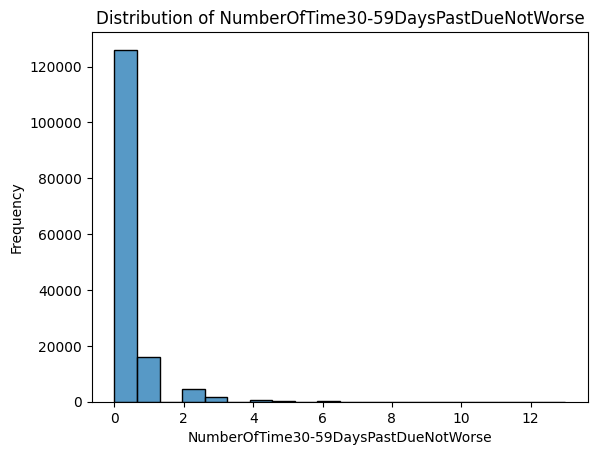

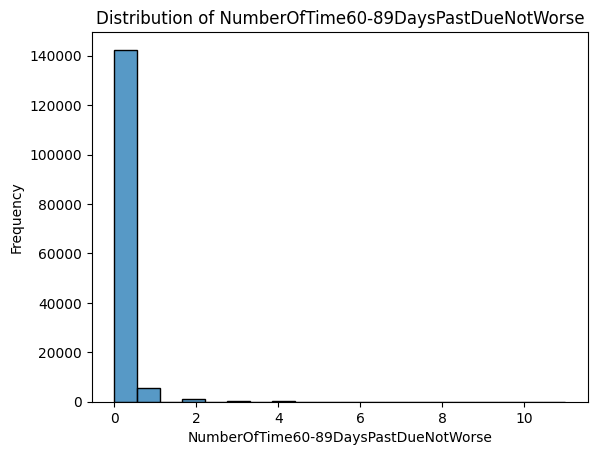

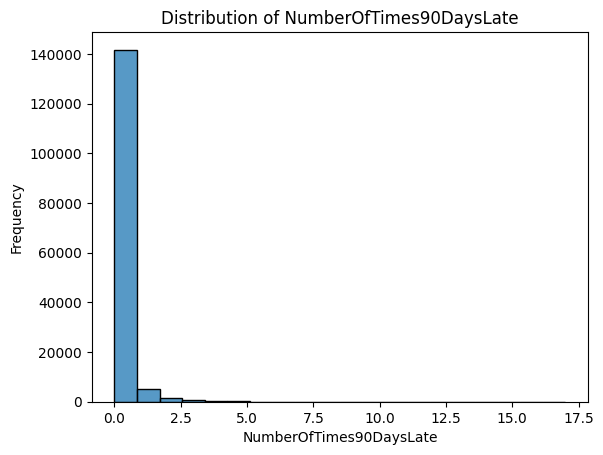

In [107]:
for col in delinq_cols:
   # plt.figure(figsize=(8, 6))
    sns.histplot(df_model[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [108]:
df_model[delinq_cols].describe(percentiles=[.25, .5, .75, .90, .95, .99, .995])

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
count,149730.000000,149730.000000,149730.000000
mean,0.245789,0.064823,0.090456
std,0.697779,0.330074,0.485529
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
90%,1.000000,0.000000,0.000000
95%,2.000000,0.000000,1.000000
99%,3.000000,2.000000,2.000000


Imputation by median and mode are equivalent in this case; we may proceed by median.

So, now our finalized choices for imputation are:
- MonthlyIncome -> Median
- NumberOfDependents -> Mode
- Delinquency variables -> Median

In [109]:
binary_features = [
    'MonthlyIncome_missing',
    'SuspiciousDelinqValue'
]

In [110]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [111]:
numeric_cols

['RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio',
 'MonthlyIncome',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [112]:
## for our pipeline we must separte NumberOfDependents

numeric_cols.pop()
numeric_cols

['RevolvingUtilizationOfUnsecuredLines',
 'DebtRatio',
 'MonthlyIncome',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse']

In [113]:
mode_feature = ['NumberOfDependents']

In [114]:
median_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

mode_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('median_pipeline', median_pipeline, numeric_cols),
    ('mode_pipeline', mode_pipeline, mode_feature),
    ('binary', 'passthrough', binary_features)
])

In [115]:
from sklearn.linear_model import LogisticRegression


In [116]:
baseline_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [117]:
baseline_pipeline.fit(X_train, y_train)

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aseem_d/Desktop/ML Projects/Lend

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('median_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['RevolvingUtilizationOfUnsecuredLines',
                                                   'DebtRatio', 'MonthlyIncome',
                                                   'age',
                                                   'NumberOfTime30-59DaysPastDueNotWorse',
                                                   'NumberOfOpenCreditLinesAndLoans',
                                                   'NumberOfTimes90DaysLate',
                                                   'NumberRealEstateLoansOrLines',
                                                   'NumberOfTime60-89DaysPastDueNotWorse']),
                                                 ('mode_pipeline',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['NumberOfDependents']),
                                                 ('binary', 'passthrough',
                                                  ['MonthlyIncome_missing',
                                                   'SuspiciousDelinqValue'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [118]:
y_pred = baseline_pipeline.predict(X_test)
y_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1]


/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending 

In [119]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

In [120]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)   
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
average_precision = average_precision_score(y_test, y_pred_proba)

In [121]:
metrics = [accuracy, precision, recall, f1, roc_auc, average_precision]
metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "Average Precision"
]
for name, metric in zip(metric_names, metrics):
    print(f"{name}: {metric:.4f}")

Accuracy: 0.9361
Precision: 0.5820
Recall: 0.1576
F1 Score: 0.2480
ROC AUC: 0.8195
Average Precision: 0.3545


In [122]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     27995
           1       0.58      0.16      0.25      2005

    accuracy                           0.94     30000
   macro avg       0.76      0.57      0.61     30000
weighted avg       0.92      0.94      0.92     30000



<Axes: >

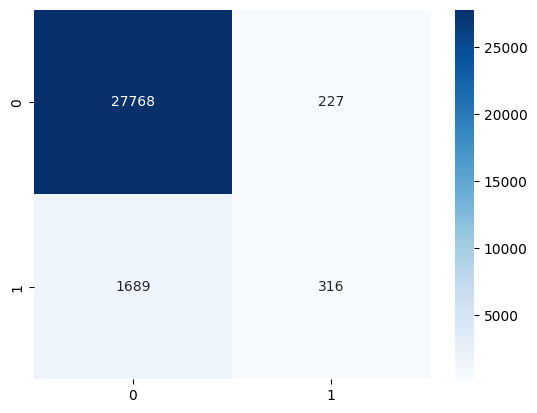

In [123]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues'
)

#### Interpretation of Baseline Model 
- Precision, and especially recall, are extremely low; as reflected in the F1-Score, which is the harmonic mean of the two quantities. What this means is that out of all the predicted positives, only 58% are accurate; and out of the total positives, it manages to correctly predict only 16%.
- The ROC-AUC score of 0.81 shows us that the model is good at discriminating between the two classes; this indicates that the recall of 0.16 may have more to do with the default threshold level not being an optimal choice, rather than the model performance being poor.
- Accuracy of 94% is achieved by this model; but this can be a misleading metric. It only tells us about the percentage of predictions the model gets correctly; due to the imbalance in the target, even classifying every single entry as the majority class would give us an accuracy of 93%.

## 7. Model Comparison — Probability Diagnostics

The following diagnostics use the frozen held-out test set and explain threshold behavior, discrimination, and calibration.

Before we move ahead with this , let us address some of the warnings that were issued by python when we were training our baseline model

In [124]:
## check for numerical stability
X_train_processed = preprocessor.fit_transform(X_train)
print("All finite values:",
      np.isfinite(X_train_processed).all())

print("Maximum absolute value:",
      np.max(np.abs(X_train_processed)))

All finite values: True
Maximum absolute value: 163.23115780578297


In [125]:
preprocessor.get_feature_names_out()

array(['median_pipeline__RevolvingUtilizationOfUnsecuredLines',
       'median_pipeline__DebtRatio', 'median_pipeline__MonthlyIncome',
       'median_pipeline__age',
       'median_pipeline__NumberOfTime30-59DaysPastDueNotWorse',
       'median_pipeline__NumberOfOpenCreditLinesAndLoans',
       'median_pipeline__NumberOfTimes90DaysLate',
       'median_pipeline__NumberRealEstateLoansOrLines',
       'median_pipeline__NumberOfTime60-89DaysPastDueNotWorse',
       'mode_pipeline__NumberOfDependents',
       'binary__MonthlyIncome_missing', 'binary__SuspiciousDelinqValue'],
      dtype=object)

In [126]:
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=preprocessor.get_feature_names_out()
)

In [127]:
X_train_processed_df.describe()

,median_pipeline__RevolvingUtilizationOfUnsecuredLines,median_pipeline__DebtRatio,median_pipeline__MonthlyIncome,median_pipeline__age,median_pipeline__NumberOfTime30-59DaysPastDueNotWorse,median_pipeline__NumberOfOpenCreditLinesAndLoans,median_pipeline__NumberOfTimes90DaysLate,median_pipeline__NumberRealEstateLoansOrLines,median_pipeline__NumberOfTime60-89DaysPastDueNotWorse,mode_pipeline__NumberOfDependents,binary__MonthlyIncome_missing,binary__SuspiciousDelinqValue
count,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,1.199990e+05,119999.000000,119999.000000
mean,-4.263292e-18,6.987062e-18,4.144867e-18,1.477349e-16,9.829256e-18,5.210690e-17,-2.214543e-17,1.312147e-16,-2.984304e-17,5.796893e-17,0.197902,0.001792
std,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,1.000004e+00,0.398419,0.042290
min,-2.774855e-02,-1.683144e-01,-5.853101e-01,-2.121812e+00,-3.518187e-01,-1.642508e+00,-1.865408e-01,-8.979398e-01,-1.969532e-01,-6.646581e-01,0.000000,0.000000
25%,-2.760202e-02,-1.682312e-01,-2.291992e-01,-7.666729e-01,-3.518187e-01,-6.721853e-01,-1.865408e-01,-8.979398e-01,-1.969532e-01,-6.646581e-01,0.000000,0.000000
50%,-2.699174e-02,-1.681403e-01,-9.223350e-02,-2.134644e-02,-3.518187e-01,-8.999171e-02,-1.865408e-01,-1.727584e-02,-1.969532e-01,-6.646581e-01,0.000000,0.000000
75%,-2.499156e-02,-1.679040e-01,9.038745e-02,7.239800e-01,-3.518187e-01,4.922019e-01,-1.865408e-01,8.633881e-01,-1.969532e-01,2.381674e-01,0.000000,0.000000
max,1.096238e+02,1.562949e+02,1.632312e+02,3.840800e+00,1.830073e+01,9.613235e+00,3.504213e+01,4.665791e+01,3.303957e+01,1.739185e+01,1.000000,1.000000


Our initial suspicioun would have been that these issues were being caused by extreme outliers that the scaler was unable to reduce the effect of; although on looking into our transformed values, this does not seem to be the case.

### Confusion Matrix Analysis
Let us analyse the confusion matrix in further detail.

In [128]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

In [129]:
conf_mtrx_val =pd.DataFrame({
    "True Negatives": [tn, 'Correctly identified low-risk borrowers'],
    "False Positives": [fp, 'Incorrectly identified low-risk borrowers as high-risk'],
    "False Negatives": [fn, 'Failed to identify high-risk borrowers'],
    "True Positives": [tp, 'Correctly identified high-risk borrowers']
})

conf_mtrx_val.T

,0,1
True Negatives,27768,Correctly identified low-risk borrowers
False Positives,227,Incorrectly identified low-risk borrowers as h...
False Negatives,1689,Failed to identify high-risk borrowers
True Positives,316,Correctly identified high-risk borrowers


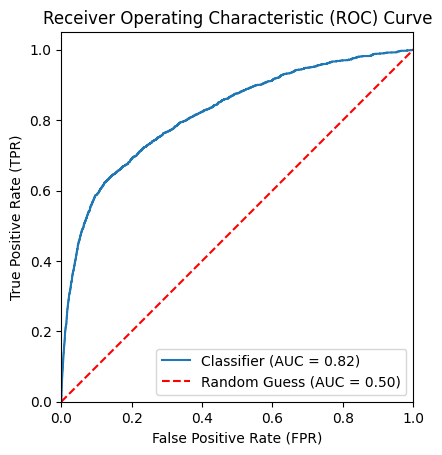

In [130]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_pred_proba
)

plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Guess (AUC = 0.50)')

# Customizing the plot boundaries and labels
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

The ROC curve plots the tradeoff between true positives and false positives as the threshold probability is varied; in other words, it tells us how well the model can rank the two classes. The area under the ROC curve (AUC) measures this discriminating ability. If the ROC-AUC is around 0.5, it tells us that the models ability to distinguish the two classes is equivalent to decisions taken on the basis of a coin toss. We want the ROC-AUC to be as close to 1 as possible; meaning that we want the model to clearly rank customers who have faced serious delinquency above those who have not.

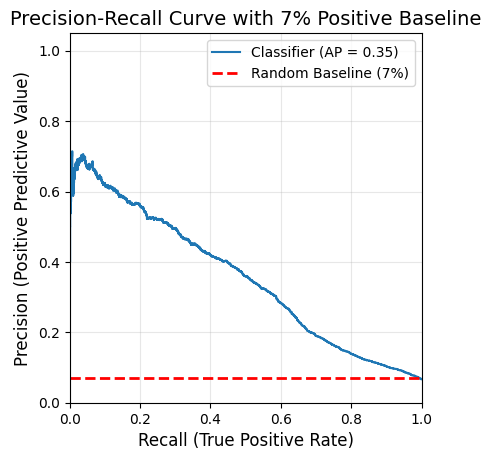

In [131]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_pred_proba
)
positive_rate = 0.07
plt.axhline(y=positive_rate, color='red', linestyle='--', lw=2, label=f'Random Baseline ({positive_rate*100:.0f}%)')


plt.xlabel('Recall (True Positive Rate)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve with 7% Positive Baseline', fontsize=14)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")

The PR-AUC curve plots the precision against the recall. It is a marker of how well the model identifies true positives without being too aggressive and generating a higher number of false postives. For a model performing well, the shape of the graph must be bow-like towards the top right corner, lying as away from the baseline as possible; meaning that it tries to maximize both precision and recall. Although high recall can only be achieved at the expense of precision, the curve lying well above the 7% baseline shows us that the model has good discriminatory ability; that said, the appropriate threshold value cannot be determined from the PR-curve alone.

### Predicted Probability Distributions

In [132]:
pred_prob_df = pd.DataFrame({
    'True Label': y_test.values,
    'Predicted Probability': y_pred_proba
})

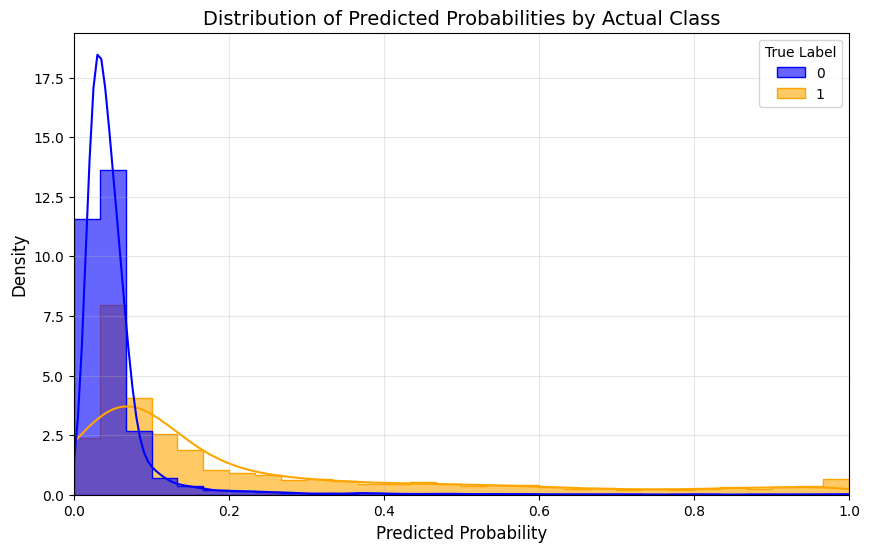

In [133]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=pred_prob_df,
    x='Predicted Probability',
    hue='True Label',
    bins=30,
    stat='density',
    common_norm=False,
    element='step',
    palette={0: 'blue', 1: 'orange'},
    alpha=0.6,
    kde=True
)
plt.title('Distribution of Predicted Probabilities by Actual Class', fontsize=14)
plt.xlabel('Predicted Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xlim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

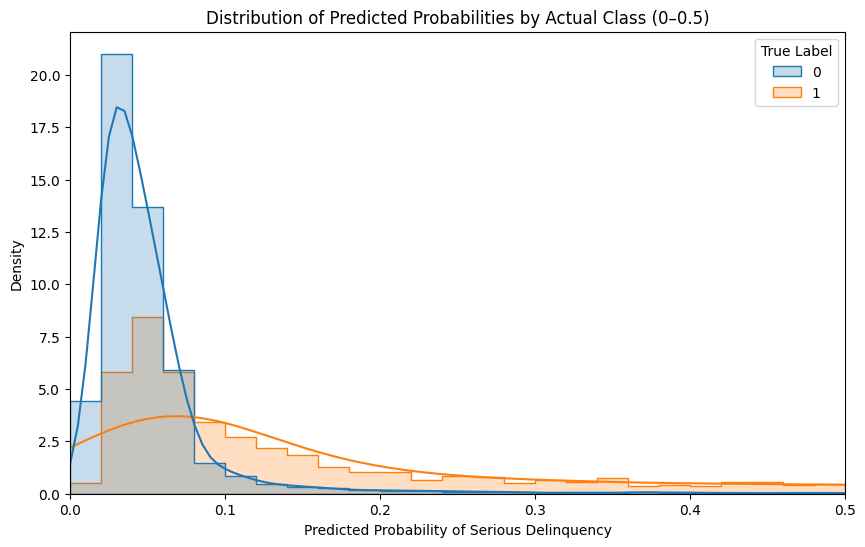

In [134]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=pred_prob_df,
    x='Predicted Probability',
    hue='True Label',
    bins=50,
    stat='density',
    common_norm=False,
    element='step',
    kde=True
)

plt.xlim(0, 0.5)

plt.title('Distribution of Predicted Probabilities by Actual Class (0–0.5)')
plt.xlabel('Predicted Probability of Serious Delinquency')
plt.ylabel('Density')

plt.show()

The substantial overlap between the predicted probability shows us that some borrowers from the two actual classes receive similar risk scores; this limits the extent to which a single threshold can separate the two classes.

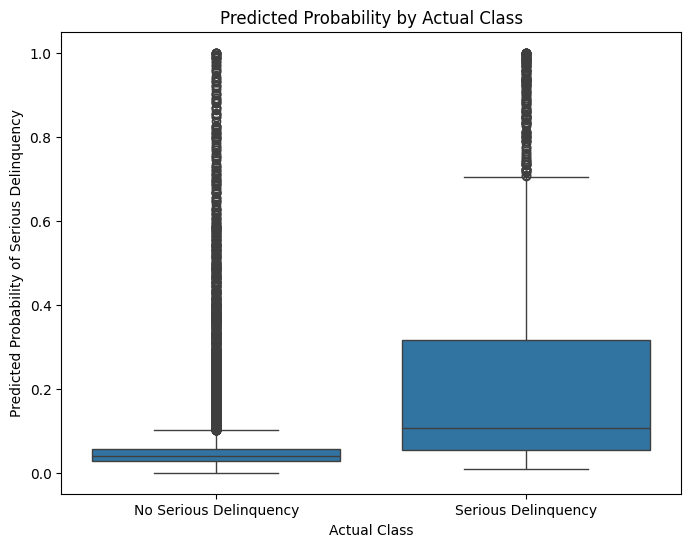

In [135]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=pred_prob_df,
    x='True Label',
    y='Predicted Probability'
)

plt.title('Predicted Probability by Actual Class')
plt.xlabel('Actual Class')
plt.ylabel('Predicted Probability of Serious Delinquency')

plt.xticks(
    [0, 1],
    ['No Serious Delinquency', 'Serious Delinquency']
)

plt.show()

The boxplot makes us think whether a lower threshold value might help us improve the metrics of the model; while recall will go up significantly, we will have to see how much of the precision is sacrificed. We must remember that changing the threshold does not improve the underlying model, it just changes the operating point of the model.

### Threshold Visualization

In [136]:
thresholds = np.arange(0.05, 0.96, 0.05)



In [137]:
## threshold vs metrics

metric_dict = {}

for t in thresholds:
    y_pred_thresh = (y_pred_proba >= t).astype(int)
    
    accuracy = accuracy_score(y_test, y_pred_thresh)
    precision = precision_score(y_test, y_pred_thresh)
    recall = recall_score(y_test, y_pred_thresh)
    f1 = f1_score(y_test, y_pred_thresh)
    high_risk_rate = y_pred_thresh.mean()*100
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    metric_dict[t] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Specificity": specificity,
        "% Classified as High Risk": high_risk_rate
    }

metric_tabl = pd.DataFrame(metric_dict).T

In [138]:
metric_tabl

,Accuracy,Precision,Recall,F1 Score,Specificity,% Classified as High Risk
0.05,0.671800,0.144270,0.793017,0.244127,0.663118,36.736667
0.10,0.902333,0.346090,0.518703,0.415170,0.929809,10.016667
0.15,0.922867,0.419068,0.399002,0.408789,0.960386,6.363333
0.20,0.929367,0.461172,0.337656,0.389865,0.971745,4.893333
0.25,0.932900,0.496633,0.294264,0.369558,0.978639,3.960000
0.30,0.934633,0.522000,0.260349,0.347421,0.982926,3.333333
0.35,0.934700,0.526437,0.228429,0.318609,0.985283,2.900000
0.40,0.935900,0.555556,0.204489,0.298943,0.988284,2.460000
0.45,0.935833,0.562500,0.179551,0.272212,0.989998,2.133333
0.50,0.936133,0.581952,0.157606,0.248038,0.991891,1.810000


We will not stress on specificity later; but it is worth noting that for almost all thresold values bar 0.05, our model correctly identifies more than 90% of the negatives.

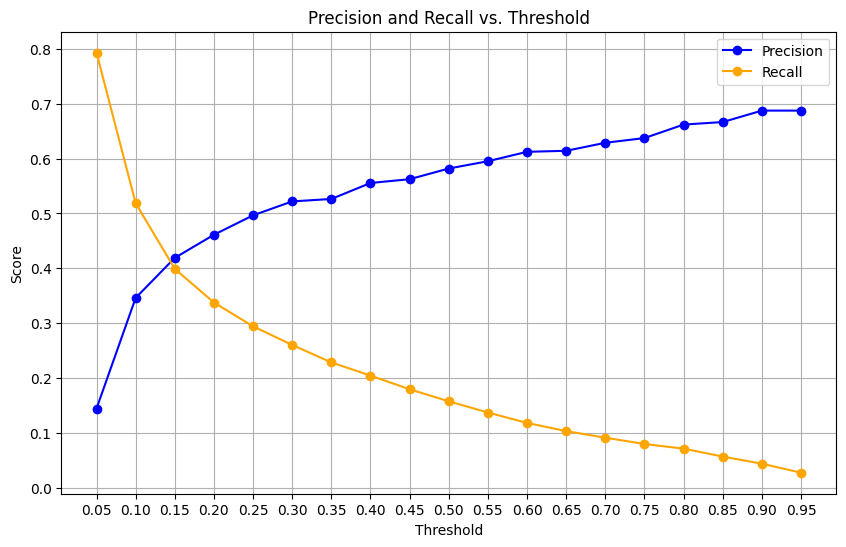

In [139]:
## threshold vs precision and recall

plt.figure(figsize=(10, 6))
plt.plot(metric_tabl.index, metric_tabl['Precision'], marker='o', label='Precision', color='blue')
plt.plot(metric_tabl.index, metric_tabl['Recall'], marker='o', label='Recall', color='orange')
plt.title('Precision and Recall vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.xticks(thresholds)
plt.grid()
plt.legend()
plt.show()

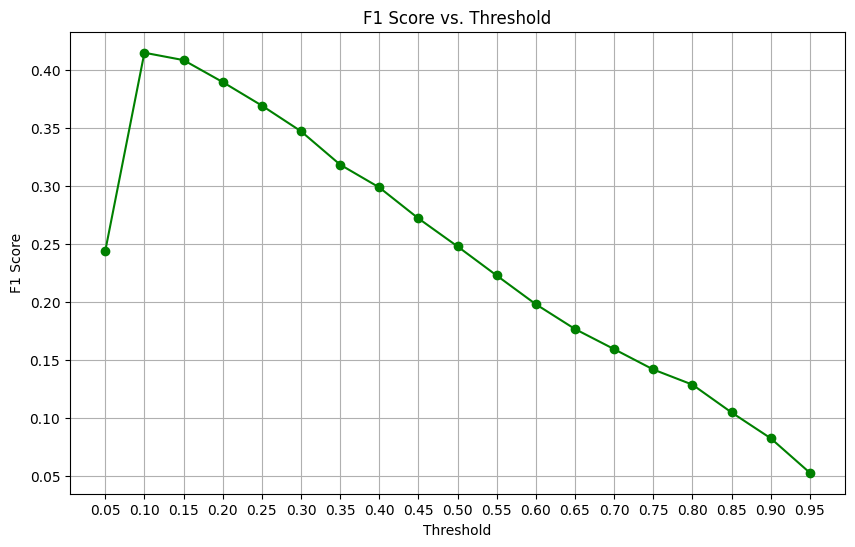

In [140]:
## threshold vs f1 score
plt.figure(figsize=(10, 6))
plt.plot(metric_tabl.index, metric_tabl['F1 Score'], marker='o', color='green')
plt.title('F1 Score vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.xticks(thresholds)
plt.grid()
plt.show()

The F1-score seems to be getting maximized at a threshold level of 0.1; even then, the maximum achieved is not high enough to justify lowering the threshold to such an extent.

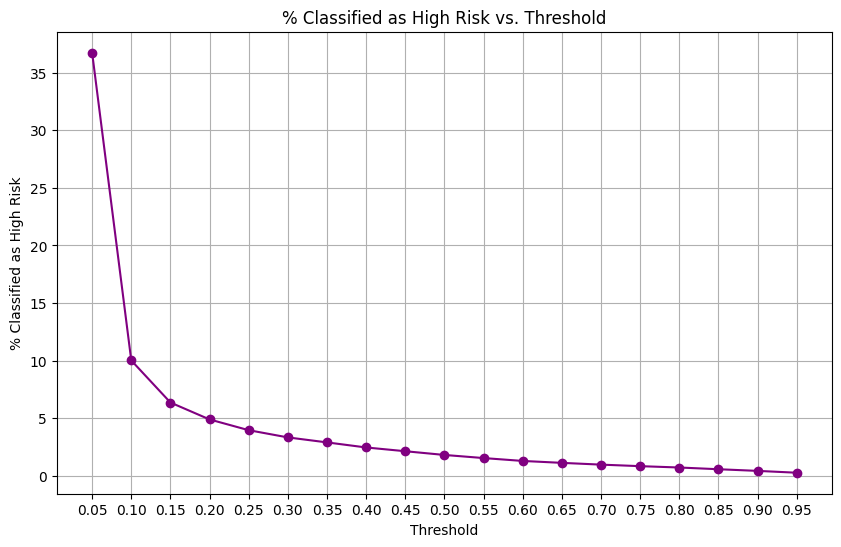

In [141]:
## threshold vs % classified as high risk
plt.figure(figsize=(10, 6))   
plt.plot(metric_tabl.index, metric_tabl['% Classified as High Risk'], marker='o', color='purple')
plt.title('% Classified as High Risk vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('% Classified as High Risk')
plt.xticks(thresholds)
plt.grid()
plt.show()

The relevance of this graph is that in a situation where we achieve very high recall; say 95%, if our model classifies 70% of the observations as positives, it is very impractical to use that threshold. In our present scenario, this graph shows us that the threshold at which we achieve the maximum possible recall, our model classifies about 37% observations as positive; in stark contrast to only the 7% actual positives present in our data. Whether this is practical or not depends upon the relative costs of false positives and false negatives.

### Analyzing misclassified observations

In [142]:
results = X_test.copy()

results['Actual'] = y_test
results['Probability'] = y_pred_proba
results['Prediction'] = y_pred

In [143]:
false_negatives = results[(results['Actual'] == 1) & (results['Prediction'] == 0)]

false_positives = results[(results['Actual'] == 0) & (results['Prediction'] == 1)]

In [144]:
false_negatives['Probability'].describe()

count    1689.000000
mean        0.131977
std         0.117343
min         0.008931
25%         0.050260
50%         0.082615
75%         0.170598
max         0.499468
Name: Probability, dtype: float64

<Axes: xlabel='Probability', ylabel='Count'>

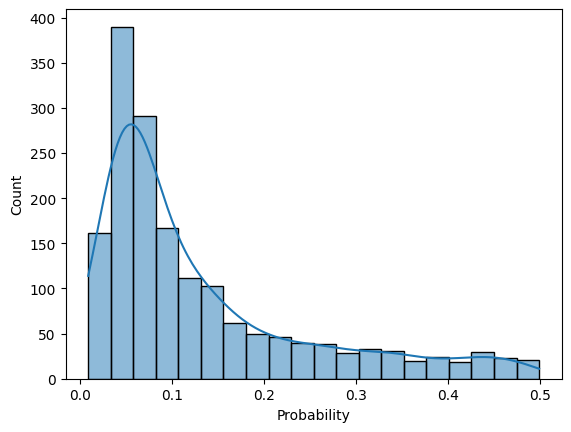

In [145]:
sns.histplot(false_negatives['Probability'], bins=20, kde=True)

A large number of false negatives (almost 50 percent) seem to be lying at probabilities lesser than 0.1; this tells us that a large number of eventual delinquents were assigned low risk by our model. 

In [146]:
false_positives['Probability'].describe()

count    227.000000
mean       0.715484
std        0.156126
min        0.501887
25%        0.575602
50%        0.690285
75%        0.849817
max        0.999928
Name: Probability, dtype: float64

<Axes: xlabel='Probability', ylabel='Count'>

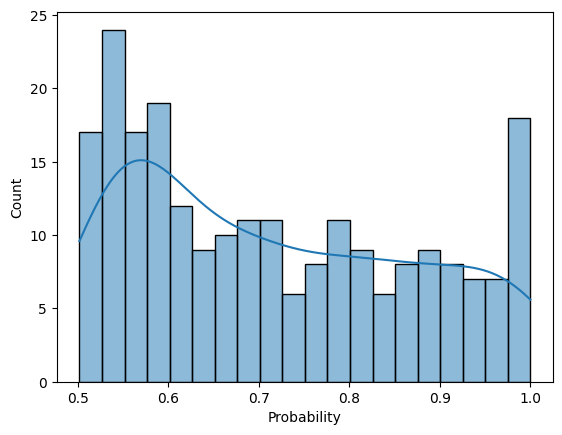

In [147]:
sns.histplot(false_positives['Probability'], bins=20, kde=True)

Our model seems to have a much larger number of false negatives relative to the false positives; in a credit risks scenario, false negatives are much more expensive than false positives. The false positives seem to be concentrated towards the decision boundary, although the same is not seen in case of the false negatives. One would expect all misclassifications to lie close to the decision boundary; why this asymmetry exists must be investigated further.

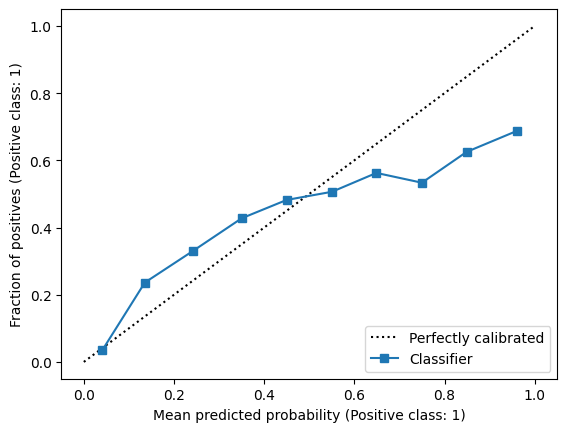

In [148]:
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(
    y_test,
    y_pred_proba,
    n_bins=10
)


The calibration curve plots the predicted probabilities of our model against the relative frequency of the positive class in the data. A good classifier follows the straight line y=x. The curve shows us that while there is deviation from the straight line, our predicted probabilities are reasonably close to the observed relative frequencies, especially for lower values. As our values increase, this deviation also seems to be increasing, with our predicted probabilities overestimating the actual relative frequencies.

## 5. Logistic Regression — Alternative Specifications

The alternatives are retained as experiments; they do not replace the final unweighted XGBoost.

Let us summarize our baseline model's metrics so that moving ahead we can use it as a reference point.

In [149]:
summary_dict = {}

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC', 'Average Precision']

summary_dict["Baseline Logistic Regression Model"] = (accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_pred_proba), average_precision_score(y_test, y_pred_proba))

summary_tabl = pd.DataFrame(summary_dict, index=metrics).T
summary_tabl

,Accuracy,Precision,Recall,F1 Score,ROC AUC,Average Precision
Baseline Logistic Regression Model,0.936133,0.581952,0.157606,0.248038,0.819548,0.354522


If you can recall-
LR-1
- Original features
- Missingness and suspicious value indicators
- Median/Mode imputation
- Standardization
- Ordinary Logistic Regression

LR-2
- All features of LR-1
- log1p transformations for continuous variables

LR-3
- ALl features of LR-2
- 'class_weight' = balanced

LR-4
- All features of LR-3 minus class weighting
- Aggregated severity weighted delinquency score

We need to train theese three models and compare the metrics to that of the baseline model, as well as to each other. However, to make the comparison fair, we must remember that each model should use:
- Exactly the same train and test splits
- Same target
- Same handling of invalid values and same treatment of suspicious values
- Preprocessing inside a pipeline
- Preprocessing only on the training data
- The same evaluation set

Let us freeze the evaluation metrics for our model by creating a function that automates the task, so that we do not have to manually calculate all metrics for each model.

In [150]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test, threshold=0.5):

    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Average Precision": average_precision_score(y_test, y_prob)
    }

Common preprocessing rules-
- Median imputation for missing monthly income values
- Mode imputation for missing number of dependents values
- Delinquency variables in 96/98 -> replace with NaN, replace with median
- Standardization


In [151]:
results_baseline = evaluate_model(baseline_pipeline, X_test, y_test)
baseline_prob = baseline_pipeline.predict_proba(X_test)[:, 1]

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aseem_d/Desktop/ML Projects/Lending 

Let us make a reproducible pipeline for training our models:

In [152]:
from sklearn.preprocessing import FunctionTransformer

def make_lr_pipeline(log_features=None, class_weight=None):

    if log_features is None:
        log_features = []

    numeric_cols = [
        'RevolvingUtilizationOfUnsecuredLines',
        'age',
        'DebtRatio',
        'MonthlyIncome',
        'NumberOfOpenCreditLinesAndLoans',
        'NumberOfTimes90DaysLate',
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
        'NumberRealEstateLoansOrLines',
    ]

    non_log_cols = [col for col in numeric_cols if col not in log_features]

    log_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p)),
        ('scaler', StandardScaler())
    ])

    dependents_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
    ])

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    preprocessor = ColumnTransformer([
        ('log', log_pipeline, log_features),
        ('numeric', numeric_pipeline, non_log_cols),
        ('dependents', dependents_pipeline, ['NumberOfDependents']),
        ('binary', 'passthrough',
         ['MonthlyIncome_missing', 'SuspiciousDelinqValue'])
    ])

    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=42,
            class_weight=class_weight
        ))
    ])

In [153]:
lr1 = make_lr_pipeline()
model_lr1 = lr1.fit(X_train, y_train)
results_lr1 = evaluate_model(lr1, X_test, y_test)
lr1_prob = lr1.predict_proba(X_test)[:, 1]

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aseem_d/Desktop/ML Projects/Lend

In [154]:
lr2 = make_lr_pipeline(log_features=[
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome'
])
model_lr2 = lr2.fit(X_train, y_train)
results_lr2 = evaluate_model(lr2, X_test, y_test)
lr2_prob = lr2.predict_proba(X_test)[:, 1]

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aseem_d/Desktop/ML Projects/Lend

In [155]:
lr3 = make_lr_pipeline(
    log_features=[
        'RevolvingUtilizationOfUnsecuredLines',
        'DebtRatio',
        'MonthlyIncome'
    ],
    class_weight='balanced'
)
model_lr3 = lr3.fit(X_train, y_train)
results_lr3 = evaluate_model(lr3, X_test, y_test)
lr3_prob = lr3.predict_proba(X_test)[:, 1]

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aseem_d/Desktop/ML Projects/Lend

In [156]:
X_train_lr4 = X_train.copy()
X_test_lr4 = X_test.copy()

X_train_lr4['TotalDelinq'] = X_train_lr4[delinq_cols].sum(axis=1, min_count=1)
X_test_lr4['TotalDelinq'] = X_test_lr4[delinq_cols].sum(axis=1, min_count=1)

In [157]:
X_train_lr4 = X_train_lr4.drop(columns=delinq_cols)
X_test_lr4 = X_test_lr4.drop(columns=delinq_cols)

In [158]:
log_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome'
]

In [159]:
numeric_cols_lr4 = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents',
    'TotalDelinq'
]

In [160]:
non_log_cols_lr4 = [
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents',
    'TotalDelinq'
]

In [161]:
log_pipeline_lr4 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

numeric_pipeline_lr4 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

dependents_pipeline_lr4 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', StandardScaler())
])

In [162]:
log_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'MonthlyIncome'
]

numeric_median_cols = [
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'TotalDelinq'
]

dependents_col = ['NumberOfDependents']

binary_cols = [
    'MonthlyIncome_missing',
    'SuspiciousDelinqValue'
]

In [163]:
preprocessor_lr4 = ColumnTransformer([
    ('log_features', log_pipeline_lr4, log_cols),
    ('numeric_features', numeric_pipeline_lr4, numeric_median_cols),
    ('dependents', dependents_pipeline_lr4, dependents_col),
    ('binary_features', 'passthrough', binary_cols)
])

In [164]:
lr4 = Pipeline([
    ('preprocessor', preprocessor_lr4),
    ('classifier', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model_lr4 = lr4.fit(X_train_lr4, y_train)
results_lr4 = evaluate_model(lr4, X_test_lr4, y_test)   
lr4_prob = lr4.predict_proba(X_test_lr4)[:, 1]

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aseem_d/Desktop/ML Projects/Lend

In [165]:
results_dict = {
    "Logistic Regression Model 1": results_lr1,
    "Logistic Regression Model 2": results_lr2,
    "Logistic Regression Model 3": results_lr3,
    "Logistic Regression Model 4": results_lr4
}

results_df = pd.DataFrame(results_dict).T   
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Logistic Regression Model 1,0.936133,0.581952,0.157606,0.248038,0.819548,0.354522
Logistic Regression Model 2,0.934833,0.542808,0.158105,0.244882,0.839651,0.358051
Logistic Regression Model 3,0.820500,0.232510,0.732668,0.352998,0.860475,0.353822
Logistic Regression Model 4,0.934533,0.535529,0.154115,0.239349,0.836128,0.348515


In [166]:
### severity weighted model
X_train_lr4_b = X_train.copy()
X_test_lr4_b = X_test.copy()

weights = [1, 2, 3]
X_train_lr4_b['TotalDelinq'] = X_train_lr4_b[delinq_cols].fillna(0).dot(weights)
X_test_lr4_b['TotalDelinq'] = X_test_lr4_b[delinq_cols].fillna(0).dot(weights)

In [167]:
X_train_lr4_b = X_train_lr4_b.drop(columns=delinq_cols)
X_test_lr4_b = X_test_lr4_b.drop(columns=delinq_cols)

In [168]:
model_lr4_b = lr4.fit(X_train_lr4_b, y_train)
results_lr4_b = evaluate_model(lr4, X_test_lr4_b, y_test)
lr4_b_prob = lr4.predict_proba(X_test_lr4_b)[:, 1]

/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aseem_d/Desktop/ML Projects/Lending Decisions/credit-risk-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aseem_d/Desktop/ML Projects/Lend

In [169]:
results_dict['Logistic Regression Model 4 (Severity Weighted)'] = results_lr4_b
results_df = pd.DataFrame(results_dict).T
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Logistic Regression Model 1,0.936133,0.581952,0.157606,0.248038,0.819548,0.354522
Logistic Regression Model 2,0.934833,0.542808,0.158105,0.244882,0.839651,0.358051
Logistic Regression Model 3,0.820500,0.232510,0.732668,0.352998,0.860475,0.353822
Logistic Regression Model 4,0.934533,0.535529,0.154115,0.239349,0.836128,0.348515
Logistic Regression Model 4 (Severity Weighted),0.935000,0.546218,0.162095,0.250000,0.839773,0.360767


We have reached a point where our Logistic Regression Model does not seem to be improving with slight alterations in preprocessing/modelling strategies; model 3 achieves the highest F1-score and Recall but has lesser precision, the severity weighted Model 4 is the second best. This points to the possibility that there may be non-linear relationships present in our data that a Logistic Regression Model may not be doing the best job of quantifying. Thus, we shall proceed by experimenting with Tree-based models- specifically Random Forests and XGBoost- and see if they do a better job of predicting the probabilities of serious delinquency.

## 6. Tree-Based Models

This section compares Random Forest and the unweighted XGBoost against the logistic regression candidates, then records the class-balanced and tuned experiments.

Today, we shall train a Random Forest model and an XGBoost model on our dataset, and compare their performance with our best-performing Logistic Regression Models. We must first freeze our dataset(to ensure fair comparison) while keeping in mind that tree-based models do not need scaling or log1p transformations that we previously used. We can create a common preprocessing pipeline for both the models.

In [170]:
X_train_T = X_train.copy()
X_test_T = X_test.copy()
y_train_T = y_train.copy()
y_test_T = y_test.copy()

In [171]:
numeric_cols_T = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberOfTimes90DaysLate',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberRealEstateLoansOrLines',
]

dependents_col_T = ['NumberOfDependents']

binary_cols_T = [
    'MonthlyIncome_missing',
    'SuspiciousDelinqValue'
]

In [172]:
median_pipeline_T = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
    ])

dependents_pipeline_T = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [173]:
preprocessor_T = ColumnTransformer([
    ('median_features', median_pipeline_T, numeric_cols_T),
    ('dependents', dependents_pipeline_T, dependents_col_T),
    ('binary_features', 'passthrough', binary_cols_T)
])

Before training the tree models, let us take a look at which models we are going to be comparing these against.

In [174]:
comparison_df = results_df.sort_values(by='F1', ascending=False).head(2)
comparison_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Logistic Regression Model 3,0.8205,0.232510,0.732668,0.352998,0.860475,0.353822
Logistic Regression Model 4 (Severity Weighted),0.9350,0.546218,0.162095,0.250000,0.839773,0.360767


In [175]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [176]:
RF = Pipeline([
    ('preprocessor', preprocessor_T),
    ('classifier', RandomForestClassifier(
        n_estimators=500,
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        class_weight=None,
        random_state=42,
        n_jobs=-1))
])

XGB = Pipeline([
    ('preprocessor', preprocessor_T),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=1,
        random_state=42,
        n_jobs=-1
    ))
])

In [177]:
model_rf = RF.fit(X_train_T, y_train_T)
results_rf = evaluate_model(RF, X_test_T, y_test_T)
rf_prob = RF.predict_proba(X_test_T)[:, 1]

In [178]:
results_rf

{'Accuracy': 0.9362333333333334,
 'Precision': 0.5712074303405573,
 'Recall': 0.18403990024937655,
 'F1': 0.2783855149000377,
 'ROC-AUC': np.float64(0.8564456246417356),
 'Average Precision': np.float64(0.3807011669904281)}

In [179]:
model_xgb = XGB.fit(X_train_T, y_train_T)
results_xgb = evaluate_model(XGB, X_test_T, y_test_T)
xgb_prob = XGB.predict_proba(X_test_T)[:, 1]

In [180]:
results_xgb

{'Accuracy': 0.9375,
 'Precision': 0.5942028985507246,
 'Recall': 0.20448877805486285,
 'F1': 0.3042671614100185,
 'ROC-AUC': np.float64(0.8696227728588869),
 'Average Precision': np.float64(0.40493470355916517)}

In [181]:
results_dict['Random Forest'] = results_rf
results_dict['XGBoost'] = results_xgb
results_df = pd.DataFrame(results_dict).T
results_df.sort_values(by='F1', ascending=False)

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
Logistic Regression Model 3,0.820500,0.232510,0.732668,0.352998,0.860475,0.353822
XGBoost,0.937500,0.594203,0.204489,0.304267,0.869623,0.404935
Random Forest,0.936233,0.571207,0.184040,0.278386,0.856446,0.380701
Logistic Regression Model 4 (Severity Weighted),0.935000,0.546218,0.162095,0.250000,0.839773,0.360767
Logistic Regression Model 1,0.936133,0.581952,0.157606,0.248038,0.819548,0.354522
Logistic Regression Model 2,0.934833,0.542808,0.158105,0.244882,0.839651,0.358051
Logistic Regression Model 4,0.934533,0.535529,0.154115,0.239349,0.836128,0.348515


- Random Forest has improved on Average Precision
- XGboost has improved both ROC-AUC and Average Precision

In [182]:
## varying thresholds for Random Forest and XGBoost
thresholds_T = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
rf_metrics = {}
xgb_metrics = {}
for t in thresholds_T:
    rf_metrics[t] = evaluate_model(RF, X_test_T, y_test_T, threshold=t)
    xgb_metrics[t] = evaluate_model(XGB, X_test_T, y_test_T, threshold=t)

rf_metrics_df = pd.DataFrame(rf_metrics).T
xgb_metrics_df = pd.DataFrame(xgb_metrics).T


In [183]:
rf_metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0.05,0.732300,0.176369,0.818953,0.290234,0.856446,0.380701
0.10,0.841600,0.253632,0.705237,0.373087,0.856446,0.380701
0.15,0.884067,0.311299,0.605985,0.411307,0.856446,0.380701
0.20,0.906767,0.364569,0.531671,0.432542,0.856446,0.380701
0.25,0.919167,0.408297,0.466334,0.435390,0.856446,0.380701
0.30,0.925967,0.440265,0.397007,0.417519,0.856446,0.380701
0.35,0.930933,0.476557,0.339651,0.396622,0.856446,0.380701
0.40,0.934233,0.514388,0.285287,0.367020,0.856446,0.380701
0.45,0.935767,0.546429,0.228928,0.322671,0.856446,0.380701
0.50,0.936233,0.571207,0.184040,0.278386,0.856446,0.380701


In [184]:
xgb_metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0.05,0.738900,0.183123,0.839900,0.300687,0.869623,0.404935
0.10,0.862933,0.282918,0.684788,0.400408,0.869623,0.404935
0.15,0.902667,0.358403,0.577556,0.442322,0.869623,0.404935
0.20,0.917867,0.407123,0.501746,0.449508,0.869623,0.404935
0.25,0.925967,0.446108,0.445885,0.445997,0.869623,0.404935
0.30,0.931600,0.485358,0.388529,0.431579,0.869623,0.404935
0.35,0.934100,0.510853,0.328678,0.400000,0.869623,0.404935
0.40,0.935667,0.535278,0.283791,0.370926,0.869623,0.404935
0.45,0.936767,0.561927,0.244389,0.340633,0.869623,0.404935
0.50,0.937500,0.594203,0.204489,0.304267,0.869623,0.404935


In [185]:
xgb_class_balanced = Pipeline([
    ('preprocessor', preprocessor_T),
    ('classifier', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        min_child_weight=1,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0,
        reg_alpha=0,
        reg_lambda=1,
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=13.5,  # Adjusted for class imbalance
        random_state=42,))
])

In [186]:
xgb_class_bal_model = xgb_class_balanced.fit(X_train_T, y_train_T)
results_xgb_class_bal = evaluate_model(xgb_class_balanced, X_test_T, y_test_T)
xgb_class_bal_prob = xgb_class_balanced.predict_proba(X_test_T)[:, 1]

In [187]:
xgb_class_bal_metrics = {}
for t in thresholds_T:
    xgb_class_bal_metrics[t] = evaluate_model(xgb_class_balanced, X_test_T, y_test_T, threshold=t)

xgb_class_bal_metrics_df = pd.DataFrame(xgb_class_bal_metrics).T
xgb_class_bal_metrics_df

,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0.05,0.089433,0.068320,0.999002,0.127893,0.869664,0.399047
0.10,0.264133,0.082428,0.988030,0.152162,0.869664,0.399047
0.15,0.425100,0.100995,0.962095,0.182800,0.869664,0.399047
0.20,0.529433,0.118688,0.940150,0.210768,0.869664,0.399047
0.25,0.598100,0.134153,0.919202,0.234136,0.869664,0.399047
0.30,0.648967,0.148673,0.899751,0.255181,0.869664,0.399047
0.35,0.692933,0.164009,0.877307,0.276355,0.869664,0.399047
0.40,0.731567,0.179457,0.844389,0.296005,0.869664,0.399047
0.45,0.767167,0.197889,0.813466,0.318337,0.869664,0.399047
0.50,0.800733,0.219223,0.773566,0.341630,0.869664,0.399047


Class weighting is not improving model discrimination while slightly reducing PR-AUC. We can proceed to tune hyperparameters without using class weights.

In [188]:
from sklearn.model_selection import GridSearchCV

In [189]:
xgb_base = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0,
    reg_alpha=0,
    reg_lambda=1,
    scale_pos_weight=1,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [190]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor_T),
    ('model', xgb_base)
])

In [191]:
param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__n_estimators': [200, 300, 500],
    'model__min_child_weight': [1, 5]
}

In [192]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='average_precision',
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [193]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('median_features',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['RevolvingUtilizationOfUnsecuredLines',
                                                                          'age',
                                                                          'DebtRatio',
                                                                          'MonthlyIncome',
                                                                          'NumberOfOpenCreditLinesAndLoans',
                                                                          'NumberOfTimes90DaysLate',
                                                                          'NumberOfTime30-59DaysPastDueNotWorse',
                                                                          'Nu...
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None,
                                                      random_state=42, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [3, 4, 5],
                         'model__min_child_weight': [1, 5],
                         'model__n_estimators': [200, 300, 500]},
             scoring='average_precision', verbose=1)

In [194]:
best_xgb = grid_search.best_estimator_

xgb_results = evaluate_model(
    best_xgb,
    X_test,
    y_test
)

In [195]:
xgb_results

{'Accuracy': 0.9368,
 'Precision': 0.5781922525107605,
 'Recall': 0.20099750623441395,
 'F1': 0.29829755736491487,
 'ROC-AUC': np.float64(0.8696439647443278),
 'Average Precision': np.float64(0.40381666236395014)}

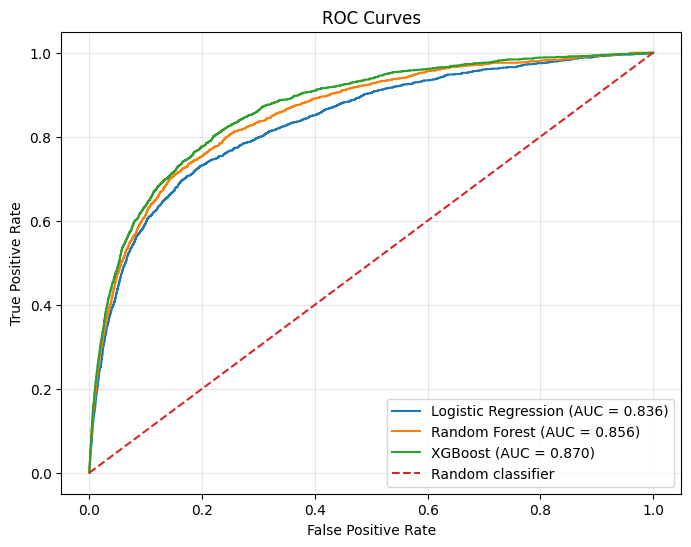

In [196]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC curves
fpr_lr4, tpr_lr4, _ = roc_curve(y_test, lr4_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test_T, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test_T, xgb_prob)

# Calculate AUC
auc_lr4 = roc_auc_score(y_test, lr4_prob)
auc_rf = roc_auc_score(y_test_T, rf_prob)
auc_xgb = roc_auc_score(y_test_T, xgb_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr4, tpr_lr4,
    label=f'Logistic Regression (AUC = {auc_lr4:.3f})'
)

plt.plot(
    fpr_rf, tpr_rf,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

plt.plot(
    fpr_xgb, tpr_xgb,
    label=f'XGBoost (AUC = {auc_xgb:.3f})'
)

plt.plot(
    [0, 1], [0, 1],
    linestyle='--',
    label='Random classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

On plotting the ROC curves for our best logistic regression model, random forest model and the unweighted XGBoost model, we can see that the XGBoost ROC curve lies above the other two; corroborating the fact that it has the highest ROC-AUC score. This implies that our XGBoost model does the best job of discriminating between customers who did and did not experience serious delinquency. 

When there is high class imbalance present in our data, the ROC-AUC score may sometimes be misleading; since the number of true negatives is always going to be extremely large, it will cause our false positive rate to shrink. Normally, a small false positive rate is considered to be good but due to the heavy class imbalance, it provides us lesser information regarding how our model ranks the two classes.

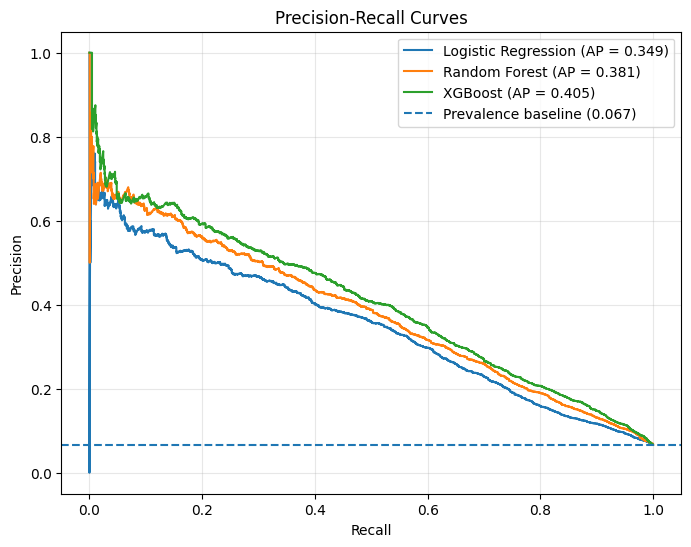

In [197]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Calculate PR curves
precision_lr4, recall_lr4, _ = precision_recall_curve(
    y_test, lr4_prob
)

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test_T, rf_prob
)

precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_test_T, xgb_prob
)

# Average Precision
ap_lr4 = average_precision_score(y_test, lr4_prob)
ap_rf = average_precision_score(y_test_T, rf_prob)
ap_xgb = average_precision_score(y_test_T, xgb_prob)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr4, precision_lr4,
    label=f'Logistic Regression (AP = {ap_lr4:.3f})'
)

plt.plot(
    recall_rf, precision_rf,
    label=f'Random Forest (AP = {ap_rf:.3f})'
)

plt.plot(
    recall_xgb, precision_xgb,
    label=f'XGBoost (AP = {ap_xgb:.3f})'
)

# Positive class prevalence
prevalence = y_test.mean()

plt.axhline(
    prevalence,
    linestyle='--',
    label=f'Prevalence baseline ({prevalence:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The PR curve for the XGBoost seems to be significantly above the Logistic Regression and Random Forest PR curves. For a random model, the expected precision is the baseline prevalence(6.7%). Our average precision tells us when our model ranks people from highest to lowest risk, it does a substantially better job (PR-AUC of 0.405) than a random model of concentrating the relatively rare delinquent cases towards the top of the model. 

In [198]:
from sklearn.metrics import brier_score_loss

brier_lr4 = brier_score_loss(y_test, lr4_prob)
brier_rf = brier_score_loss(y_test_T, rf_prob)
brier_xgb = brier_score_loss(y_test_T, xgb_prob)

brier_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Brier Score': [
        brier_lr4,
        brier_rf,
        brier_xgb
    ]
})

brier_results

,Model,Brier Score
0,Logistic Regression,0.052968
1,Random Forest,0.049861
2,XGBoost,0.048735


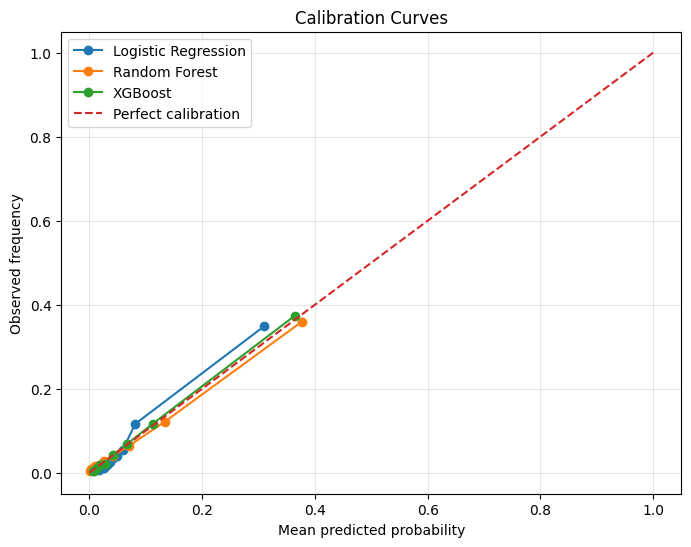

In [199]:
from sklearn.calibration import calibration_curve

# Calculate calibration curves
prob_true_lr4, prob_pred_lr4 = calibration_curve(
    y_test,
    lr4_prob,
    n_bins=10,
    strategy='quantile'
)

prob_true_rf, prob_pred_rf = calibration_curve(
    y_test_T,
    rf_prob,
    n_bins=10,
    strategy='quantile'
)

prob_true_xgb, prob_pred_xgb = calibration_curve(
    y_test_T,
    xgb_prob,
    n_bins=10,
    strategy='quantile'
)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    prob_pred_lr4,
    prob_true_lr4,
    marker='o',
    label='Logistic Regression'
)

plt.plot(
    prob_pred_rf,
    prob_true_rf,
    marker='o',
    label='Random Forest'
)

plt.plot(
    prob_pred_xgb,
    prob_true_xgb,
    marker='o',
    label='XGBoost'
)

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Perfect calibration'
)

plt.xlabel('Mean predicted probability')
plt.ylabel('Observed frequency')
plt.title('Calibration Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

The calibration curve of the XGBoost model has the least deviation from the line representing the perfect classifier.

## 8. Model Interpretation

In [200]:
calibration_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'ROC-AUC': [
        auc_lr4,
        auc_rf,
        auc_xgb
    ],
    'Average Precision': [
        ap_lr4,
        ap_rf,
        ap_xgb
    ],
    'Brier Score': [
        brier_lr4,
        brier_rf,
        brier_xgb
    ]
})

calibration_results

,Model,ROC-AUC,Average Precision,Brier Score
0,Logistic Regression,0.836128,0.348515,0.052968
1,Random Forest,0.856446,0.380701,0.049861
2,XGBoost,0.869623,0.404935,0.048735


In [201]:
import shap
xgb_preprocessor = XGB.named_steps['preprocessor']
xgb_model = XGB.named_steps['classifier']

In [202]:
X_test_xgb = xgb_preprocessor.transform(X_test_T)

In [203]:
feature_names = xgb_preprocessor.get_feature_names_out()

In [204]:
X_test_xgb_df = pd.DataFrame(
    X_test_xgb,
    columns=feature_names,
    index=X_test_T.index
)

In [205]:
X_test_xgb_df.head()

,median_features__RevolvingUtilizationOfUnsecuredLines,median_features__age,median_features__DebtRatio,median_features__MonthlyIncome,median_features__NumberOfOpenCreditLinesAndLoans,median_features__NumberOfTimes90DaysLate,median_features__NumberOfTime30-59DaysPastDueNotWorse,median_features__NumberOfTime60-89DaysPastDueNotWorse,median_features__NumberRealEstateLoansOrLines,dependents__NumberOfDependents,binary_features__MonthlyIncome_missing,binary_features__SuspiciousDelinqValue
104532,0.000000,39.0,0.412698,8000.0,7.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0
98812,0.013844,59.0,0.102674,5833.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
41147,0.000155,59.0,0.491822,11249.0,16.0,0.0,0.0,0.0,3.0,2.0,0.0,0.0
16524,0.040508,39.0,95.000000,5400.0,11.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
120157,0.257564,42.0,0.333333,7400.0,15.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [206]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_xgb_df)

In [207]:
shap_values.shape
X_test_xgb_df.shape

(30000, 12)

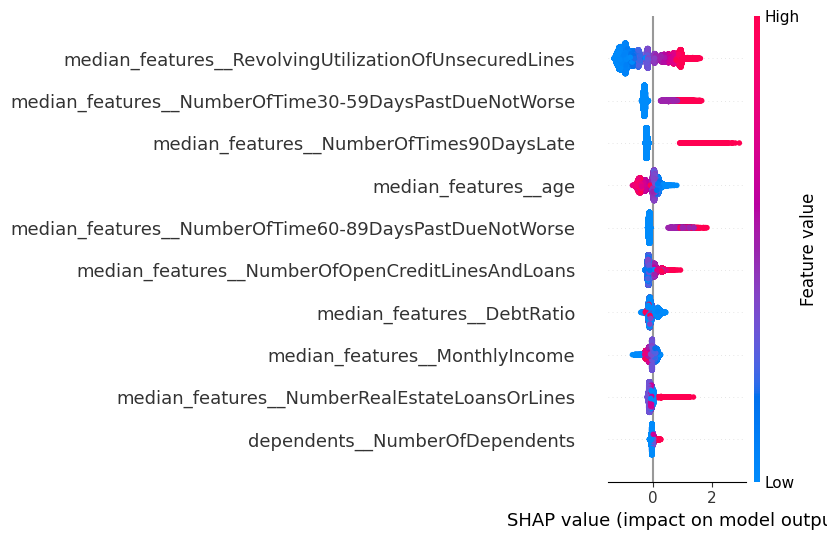

In [208]:
shap.summary_plot(
    shap_values,
    X_test_xgb_df,
    max_display=10
)

## 9. Final Model

- Higher values of delinquency features push our model to assign higher risk
- Same with NumberRealEstateLoansOrLines and NumberOFOpenCreditLinesAndLoans
- RevolvingUtilizationOfUnsecuredLines seems to have a direct contribution to the risks assigned by our model
- Age seems to be contributing inversely to the risk
- MonthlyIncome, DebtRatio do not show any such patterns regarding how they contribute to the risk

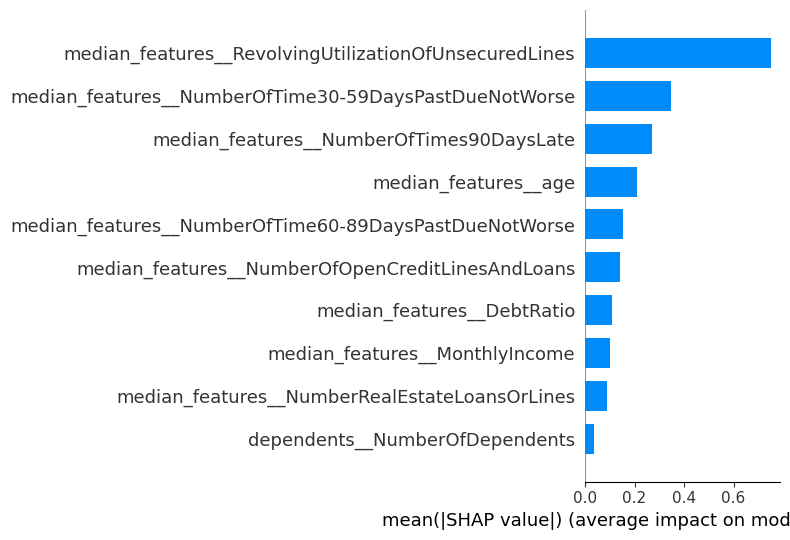

In [209]:
shap.summary_plot(
    shap_values,
    X_test_xgb_df,
    plot_type='bar',
    max_display=10
)

In [210]:
# final model selection based on F1 score, ROC-AUC, Average Precision, and Brier Score
final_model = model_xgb
final_model_name = "XGBoost"
final_model_results = results_xgb
final_model_prob = xgb_prob


In [211]:
final_model_results_df = pd.DataFrame({
    'Metric': list(final_model_results.keys()),
    'Value': list(final_model_results.values())
})

In [212]:
final_model_results

{'Accuracy': 0.9375,
 'Precision': 0.5942028985507246,
 'Recall': 0.20448877805486285,
 'F1': 0.3042671614100185,
 'ROC-AUC': np.float64(0.8696227728588869),
 'Average Precision': np.float64(0.40493470355916517)}

In [215]:
# add sensitivity and specificity to the final model results
tn, fp, fn, tp = confusion_matrix(y_test_T, (final_model_prob >= 0.5).astype(int)).ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
final_model_results['Sensitivity'] = sensitivity
final_model_results['Specificity'] = specificity

In [216]:
final_model_results

{'Accuracy': 0.9375,
 'Precision': 0.5942028985507246,
 'Recall': 0.20448877805486285,
 'F1': 0.3042671614100185,
 'ROC-AUC': np.float64(0.8696227728588869),
 'Average Precision': np.float64(0.40493470355916517),
 'Sensitivity': np.float64(0.20448877805486285),
 'Specificity': np.float64(0.9899982139667798)}

In [217]:
final_model_results_df = pd.DataFrame({
    'Metric': list(final_model_results.keys()),
    'Value': list(final_model_results.values())
})

## 10. Limitations and Future Scope

In [218]:
final_model_results_df

,Metric,Value
0,Accuracy,0.937500
1,Precision,0.594203
2,Recall,0.204489
3,F1,0.304267
4,ROC-AUC,0.869623
5,Average Precision,0.404935
6,Sensitivity,0.204489
7,Specificity,0.989998


In [220]:
# add brier score to the final model results
brier_score = brier_score_loss(y_test_T, final_model_prob)
final_model_results['Brier Score'] = brier_score
final_model_results_df = pd.DataFrame({
    'Metric': list(final_model_results.keys()),
    'Value': list(final_model_results.values())
})  

In [221]:
final_model_results_df

,Metric,Value
0,Accuracy,0.937500
1,Precision,0.594203
2,Recall,0.204489
3,F1,0.304267
4,ROC-AUC,0.869623
5,Average Precision,0.404935
6,Sensitivity,0.204489
7,Specificity,0.989998
8,Brier Score,0.048735


# 11. Conclusion
We started this project with an aim to model probability that a person experiences serious delinquency in the next two years. The data used was the 'Give Me Some Credit' dataset from Kaggle. Over the course of the project, let us look at what we discovered and how it changed our approach to the problem.

## Initial Approach
- We aimed to use a logistic regression model to predict the probabilities of delinquency.
- Initially, we aimed to not rely on a arbitrary threshold to classify people as delinquency or not delinquency, but instead work towards computing and minimizing an expected cost function that takes into account the profit of a customer repaying the loan, the loss of a customer committing default and the opportunity cost of denying a customer a loan. On further deliberation, we settled on limiting this project to a prediction of probability problem, while we may pursue the problem of minimizing the expected cost function in the future.
- On conducting exploratory data analysis on the dataset, we found a number of issues with the data quality- extreme class imbalance in the target, missing values in monthly income and number of dependents, very high values for revolving utilization and debt ratios, highly suspicious values in past delinquency variables- with some issues in one variable relating to those in others.
- We deliberated on multiple strategies to handle these issues after exploring the distribution of each individual variables.
- We trained multiple logistic regression models, each with a slightly different strategy towards transformation, feature engineering and handling class imbalance; only to find that the model performance was plateauing.
- The two best logistic regression models took into account high penalties for misclassifying positives, and reduced dimensionality by including a single severity-weighted delinquency variable, respecitvely. 

| Model | ROC-AUC | PR-AUC | F1-Score |
|---|---|---|---|
| Class Balanced Logistic Regression | 0.860475 | 0.353822 | 0.352998 |
| Severity-Weighted Logistic Regression | 0.839773 | 0.360767 | 0.25 |


## Change of Direction and Results
- The results of the logistic regression model seemed to be pointing towards its failure in capturing non-linear relationships between the predictors and the target; this was the motivation behind experimenting with tree models such as Random Forest and XGBoost.
- On experimenting with these two models, we found XGBoost to be performing better than all our previous models; then we tried tuning hyperparameters and finding the optimal model only for the initial model to still have the best results; ROC-AUC- 0.869623, PR-AUC- 0.404935, F1-Score- 0.304267 (Keep in mind that ROC and PR area under curve values are threshold agnostic, while F1-Score is measured at the default threshold of 0.5. At a threshold probability of 0.2, our XGBoost model achieves an F1-Score of 0.449508). The model also achieves a very low Brier score of 0.048735 (The Brier Score measures the average squared deviation of predicted probabilities from the actual outcome).
- Since tree models such as XGBoost do not give us coeffecients as logistic regression would, we rely on SHAP values to interpret which variables contribute to the model prediction, in which direction. We find that the delinquency features to have the highest direct contribution to the risk, while the age has the highest inverse contribution to the risk.

## 11. Conclusion
- Tree models are more suitable to capturing complex, non-linear relationships. In our case, the improvement in model performance was significant enough for us to opt for XGBoost over the highly-interpretable logistic regression model.
- Handling messy data was the one of the biggest challenges of the project; it taught us to deliberate on strategies towards imputation and transformation very carefully, and not arriving at any conclusions without thorough consideration.
- The metric of our final model that we must focus on the most is the PR-AUC of 0.404935. The severe class imbalance present in our dataset (only 6.7% positives) means that while a high ROC-AUC value does tell us that our model can discriminate between the two classes, it does tell us how well it concentrates the positives towards the top of the risk rankings. The PR-AUC score tells us that our model does close to 6 times better of a job than a random model that simply assigns a 0.067 probability of delinquency to every observation. 
- In the future, we may move towards minimizing an expected cost function, by assigning a relative cost ratio  of False Negatives and False Positives; then we may reach an optimal threshold value depending upon how severe this ratio is.
- Since the relationships between the variables and the target, and between the variables themselves are severy complicated, a Neural Network based approach might provide us better results. We may use this approach in the future.


## 12. Reproducible deployment and evaluation export

This final section exports the selected unweighted XGBoost pipeline and the same held-out evaluation metrics and calibration coordinates used above. The application only loads these artifacts; it does not fit or evaluate models. Run the notebook from the repository root after placing the training CSV there.


In [ ]:
from pathlib import Path
import json
import joblib
from sklearn.calibration import calibration_curve

root = Path.cwd()
(root / "models").mkdir(exist_ok=True)
(root / "results").mkdir(exist_ok=True)
(root / "assets").mkdir(exist_ok=True)

# final_model is model_xgb: the selected, unweighted XGBoost pipeline.
joblib.dump(final_model, root / "models" / "final_xgb_model.joblib")

metric_rows = calibration_results.rename(columns={
    "Model": "name", "ROC-AUC": "roc_auc",
    "Average Precision": "average_precision", "Brier Score": "brier_score"
}).to_dict(orient="records")
artifact = {
    "source": "notebooks/credit_risk_analysis.ipynb, held-out test set",
    "evaluation": "test_size=0.2, random_state=42, stratified split",
    "models": metric_rows,
    "final_model": "XGBoost",
    "final_model_threshold_metrics": {k: float(v) for k, v in final_model_results.items()}
}
(root / "results" / "model_metrics.json").write_text(json.dumps(artifact, indent=2) + "\n")

calibration = {}
for name, y_true, probabilities in [
    ("Logistic Regression", y_test, lr4_prob),
    ("Random Forest", y_test_T, rf_prob),
    ("XGBoost", y_test_T, xgb_prob),
]:
    observed, predicted = calibration_curve(y_true, probabilities, n_bins=10, strategy="quantile")
    calibration[name] = {"mean_predicted": predicted.tolist(), "observed_frequency": observed.tolist()}
(root / "results" / "calibration_curves.json").write_text(json.dumps(calibration, indent=2) + "\n")

# Save dashboard-sized versions of the notebook's ROC, PR, and calibration figures.
fig, ax = plt.subplots(figsize=(7, 5))
for label, fpr, tpr in [("Logistic Regression", fpr_lr4, tpr_lr4), ("Random Forest", fpr_rf, tpr_rf), ("XGBoost", fpr_xgb, tpr_xgb)]:
    ax.plot(fpr, tpr, label=label)
ax.plot([0, 1], [0, 1], "--", color="gray"); ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves"); ax.legend(); fig.tight_layout(); fig.savefig(root / "assets" / "roc_curve.png", dpi=160); plt.close(fig)
fig, ax = plt.subplots(figsize=(7, 5))
for label, recall, precision in [("Logistic Regression", recall_lr4, precision_lr4), ("Random Forest", recall_rf, precision_rf), ("XGBoost", recall_xgb, precision_xgb)]:
    ax.plot(recall, precision, label=label)
ax.axhline(y_test.mean(), linestyle="--", color="gray", label="Test prevalence"); ax.set(xlabel="Recall", ylabel="Precision", title="Precision–Recall Curves"); ax.legend(); fig.tight_layout(); fig.savefig(root / "assets" / "pr_curve.png", dpi=160); plt.close(fig)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
for name, values in calibration.items(): ax.plot(values["mean_predicted"], values["observed_frequency"], marker="o", label=name)
ax.set(xlabel="Mean predicted probability", ylabel="Observed frequency", title="Calibration Curves"); ax.legend(); fig.tight_layout(); fig.savefig(root / "assets" / "calibration_curve.png", dpi=160); plt.close(fig)
